## 🏷️OBJETIVO DEL PRESENTE CUADERNO (EDA)

EDA (Análisis Exploratorio de Datos) y su objetivo es entregar el "Tablón Maestro", la higienización (pasar columnas a minúsculas, quitar espacios y purgar duplicados).

## 🔧 0. Preparación del entorno, instalación e importación de librerías

Primero importamos todas las librerías que vamos a necesitar. Si alguna no la tienes instalada, la celda siguiente la instala.

**Nota sobre las librerías:**
- `numpy` y `pandas`: manipulación de datos.
- `matplotlib` y `seaborn`: visualización.
- `scipy.stats`: tests estadísticos (normalidad, correlaciones).
- `scikit-learn`: todo lo relacionado con ML (imputación, detección de outliers, pipelines).

In [2]:
# ==============================================================================
# INSTALACIÓN FORZADA DENTRO DEL KERNEL ACTIVO
# Usamos sys.executable para asegurarnos de que se instale en este entorno exacto
# ==============================================================================
import sys

print(f"Instalando librerías en el entorno actual: {sys.executable}")

# Ejecutamos la instalación asegurando que apunte al ejecutable de esta celda
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy scikit-learn

Instalando librerías en el entorno actual: c:\Users\Carlos\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
# ==============================================================================
# Preparación del Entorno e Importación de Librerías
# ==============================================================================

import os
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Librerías avanzadas para diagnóstico y preparación del modelado
from sklearn.experimental import enable_iterative_imputer  # Permite imputación avanzada si se requiere
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.ensemble import IsolationForest  # Para detección robusta de outliers estadísticos

# Desactivar alertas que puedan ensuciar la presentación del cuaderno
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# Configuración Estética y Visualización (Orientado a Reportes Ejecutivos)
# ------------------------------------------------------------------------------
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Configuración de despliegue en Pandas (Evita que los datos largos se recorten)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Garantizar reproducibilidad en análisis estocásticos o muestreos
SEED = 42
np.random.seed(SEED)

print("✅ Librerías del ecosistema de Datos e IA cargadas correctamente.")
print(f"-> NumPy versión: {np.__version__}")
print(f"-> Pandas versión: {pd.__version__}")

✅ Librerías del ecosistema de Datos e IA cargadas correctamente.
-> NumPy versión: 2.2.5
-> Pandas versión: 2.2.3


## 📂 1. Gestión de Rutas y Carga de los Datasets a través de los archivos csv ubicados en data / raw
Para evitar romper el código si mueves la carpeta o si el proyecto se evalúa en otra máquina, utilizaremos una función defensiva que verifica la existencia de cada archivo antes de intentar cargarlo a memoria.

In [4]:
# ==============================================================================
# Fase: 1. Definición de Rutas Estructuradas y Carga Defensiva de Datos
# ==============================================================================

# Definimos la ruta base del proyecto usando Pathlib (compatible con cualquier Sistema Operativo)
# Nota: Modifica esta variable si ejecutas el proyecto desde otra raíz.
RUTA_PROYECTO = Path(r"C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce")
RUTA_RAW = RUTA_PROYECTO / "data" / "raw"

# Diccionario que mapea el nombre del dataset con su respectivo archivo físico
archivos_ecommerce = {
    'interactions': 'interactions.csv',
    'products': 'products.csv',
    'purchases': 'purchases.csv',
    'reviews': 'reviews.csv',
    'sessions': 'sessions.csv',
    'users': 'users.csv'
}

# Almacén dinámico para nuestros DataFrames
datasets = {}

print("--> Iniciando carga segura de archivos del ecosistema e-commerce:")
for nombre, archivo in archivos_ecommerce.items():
    ruta_completa = RUTA_RAW / archivo
    
    # Estructura de control para mitigar errores de rutas ausentes
    if ruta_completa.exists():
        try:
            # Cargamos el archivo de manera estándar
            datasets[nombre] = pd.read_csv(ruta_completa)
            print(f"   ✅ {nombre.upper().ljust(13)} cargado correctamente. Registros: {datasets[nombre].shape[0]:,} | Columnas: {datasets[nombre].shape[1]}")
        except Exception as e:
            print(f"   ❌ Error al leer el archivo {archivo}: {str(e)}")
    else:
        print(f"   ❌ Alerta: No se encontró el archivo en la ruta esperada: {ruta_completa}")

# Desempaquetado explícito para trabajar de forma cómoda en las siguientes celdas
df_interactions = datasets.get('interactions')
df_products     = datasets.get('products')
df_purchases    = datasets.get('purchases')
df_reviews      = datasets.get('reviews')
df_sessions     = datasets.get('sessions')
df_users        = datasets.get('users')

--> Iniciando carga segura de archivos del ecosistema e-commerce:
   ✅ INTERACTIONS  cargado correctamente. Registros: 100,000 | Columnas: 7
   ✅ PRODUCTS      cargado correctamente. Registros: 1,000 | Columnas: 11
   ✅ PURCHASES     cargado correctamente. Registros: 1,737 | Columnas: 10
   ✅ REVIEWS       cargado correctamente. Registros: 1,253 | Columnas: 8
   ✅ SESSIONS      cargado correctamente. Registros: 19,315 | Columnas: 6
   ✅ USERS         cargado correctamente. Registros: 10,000 | Columnas: 9


## 📋 2. Diagnóstico Estructural de los 6 df creados para c/u de las Entidades de Negocio

Los siguientes dos scripts son la Aduana de Entrada a la fábrica:

Su función: Analizan los camiones que llegan directamente del campo con los datos crudos (data/raw). Su único objetivo es medir e informar: "la estructura, nulos, duplicados,.., de c/u de las tablas iniciales". Sirve para saber como estan los datos originalmente sin modificarlos a fin de conservar la integridad inicial, modificarlos aquí perderíamos el dignostico inicial y no sabríamos si venían defectuosos desde el origen.

In [5]:
# ==============================================================================
# Objetivo: Crear un esqueleto reutilizable para diagnosticar cualquier DataFrame
# ==============================================================================

def auditar_dataframe(df, nombre_df="DataFrame"):
    """
    Realiza una auditoría completa de la estructura de un DataFrame.
    Detecta tipos de datos, conteo de nulos, porcentajes de ausencia y cardinalidad.
    """
    if df is None:
        print(f"El DataFrame '{nombre_df}' no está disponible para auditoría.")
        return None
        
    print("-" * 80)
    print(f"📊 REPORTE DE AUDITORÍA INICIAL: {nombre_df.upper()}")
    print("-" * 80)
    print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas\n")
    
    # Construcción de la matriz de metadatos de forma generalista
    reporte = pd.DataFrame({
        'Tipo_Dato': df.dtypes,
        'Valores_No_Nulos': df.count(),
        'Valores_Nulos': df.isnull().sum(),
        'Porcentaje_Nulos': (df.isnull().sum() / len(df)) * 100,
        'Valores_Unicos': df.nunique()
    })
    
    # Identificar potenciales claves primarias/foráneas por alta variabilidad de datos
    reporte['Potencial_Key'] = reporte['Valores_Unicos'].apply(
        lambda x: 'Sí' if x > (len(df) * 0.9) else 'No'
    )
    
    # Mostramos el reporte elegante en el cuaderno
    display(reporte)
    print("\n")
    return reporte

In [6]:
# ==============================================================================
# Fase: 2. Ejecución de la Auditoría Automatizada del Ecosistema de Datos
# Objetivo: Identificar nulos, inconsistencias de tipos y claves de unión (Keys)
# ==============================================================================

# Diccionario para almacenar los informes individuales por si los necesitamos después
informes_auditoria = {}

print("=======================================================================")
print(" INICIANDO AUDITORÍA GENERAL DE CALIDAD DE DATOS (DATA QUALITY)")
print("=======================================================================\n")

# Iteramos sobre nuestro almacén de datasets cargados en la fase anterior
for nombre_tabla, df_tabla in datasets.items():
    # Ejecutamos la función generalista que definimos previamente
    informes_auditoria[nombre_tabla] = auditar_dataframe(df_tabla, nombre_tabla)
    
print("▶️ Diagnóstico completado. Revisa las tablas superiores para el análisis técnico.")

 INICIANDO AUDITORÍA GENERAL DE CALIDAD DE DATOS (DATA QUALITY)

--------------------------------------------------------------------------------
📊 REPORTE DE AUDITORÍA INICIAL: INTERACTIONS
--------------------------------------------------------------------------------
Dimensiones: 100,000 filas x 7 columnas



,Tipo_Dato,Valores_No_Nulos,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Potencial_Key
interaction_id,object,100000,0,0.00,100000,Sí
user_id,object,100000,0,0.00,6944,No
product_id,object,100000,0,0.00,967,No
session_id,object,100000,0,0.00,19315,No
interaction_type,object,100000,0,0.00,6,No
timestamp,object,100000,0,0.00,96257,Sí
dwell_time_ms,int64,100000,0,0.00,38900,No




--------------------------------------------------------------------------------
📊 REPORTE DE AUDITORÍA INICIAL: PRODUCTS
--------------------------------------------------------------------------------
Dimensiones: 1,000 filas x 11 columnas



,Tipo_Dato,Valores_No_Nulos,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Potencial_Key
product_id,object,1000,0,0.00,1000,Sí
product_name,object,1000,0,0.00,857,No
product_description,object,1000,0,0.00,1000,Sí
category,object,1000,0,0.00,10,No
subcategory,object,1000,0,0.00,53,No
brand,object,1000,0,0.00,137,No
price,float64,1000,0,0.00,955,Sí
rating_avg,float64,452,548,54.80,21,No
review_count,int64,1000,0,0.00,26,No
stock_quantity,int64,1000,0,0.00,72,No




--------------------------------------------------------------------------------
📊 REPORTE DE AUDITORÍA INICIAL: PURCHASES
--------------------------------------------------------------------------------
Dimensiones: 1,737 filas x 10 columnas



...



--------------------------------------------------------------------------------
📊 REPORTE DE AUDITORÍA INICIAL: SESSIONS
--------------------------------------------------------------------------------
Dimensiones: 19,315 filas x 6 columnas



,Tipo_Dato,Valores_No_Nulos,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Potencial_Key
session_id,object,19315,0,0.00,19315,Sí
user_id,object,19315,0,0.00,6944,No
start_time,object,19315,0,0.00,19315,Sí
device_type,object,19315,0,0.00,3,No
referrer_source,object,19315,0,0.00,7,No
is_converted,bool,19315,0,0.00,2,No




--------------------------------------------------------------------------------
📊 REPORTE DE AUDITORÍA INICIAL: USERS
--------------------------------------------------------------------------------
Dimensiones: 10,000 filas x 9 columnas



,Tipo_Dato,Valores_No_Nulos,Valores_Nulos,Porcentaje_Nulos,Valores_Unicos,Potencial_Key
user_id,object,10000,0,0.00,10000,Sí
age,int64,10000,0,0.00,58,No
gender,object,10000,0,0.00,4,No
country,object,10000,0,0.00,20,No
city,object,10000,0,0.00,7679,No
signup_date,object,10000,0,0.00,1241,No
income_level,object,10000,0,0.00,4,No
preferred_category,object,10000,0,0.00,10,No
loyalty_tier,object,10000,0,0.00,4,No




▶️ Diagnóstico completado. Revisa las tablas superiores para el análisis técnico.


🕵️‍♂️ Conclusiones de la Auditoría (Diagnóstico de Calidad)
1. Las Buenas Noticias (Datos sumamente limpios)
Ausencia de Nulos Casi Total: Prácticamente todo está al 100% de ocupación. Significa que el sistema de registro de la web funciona muy bien.

Trazabilidad Perfecta (Keys): las variables terminadas en _id tienen la consistencia ideal. user_id tiene 10,000 valores únicos en la tabla de USERS (un registro único por cliente) y se repite de forma lógica 19,315 veces en SESSIONS e INTERACTIONS. El ecosistema es perfectamente integrable.

2. Las Alarmas a Corregir:
🚨 El Problema de Fechas (Crítico): Las columnas timestamp (interactions), date_added (products), order_date (purchases), review_date (reviews) y signup_date (users) están tipificadas como object (texto). No se puede hacer analítica temporal con texto. Las transformaremos a formato fecha real.

🚨 Los Nulos Ocultos de los Productos (rating_avg): La tabla PRODUCTS tiene un 54.80% de nulos en la columna rating_avg (calificación promedio). ¡Casi la mitad de los productos no tienen calificación! Esto ocurre mucho en tiendas reales: productos nuevos o poco populares que nadie valora. Diseñaremos una estrategia para rellenar esto (imputación por ceros o por la media de su categoría o no tomarla encuenta).

🚨 Las Reseñas Anónimas (purchase_id): En REVIEWS, el campo purchase_id tiene un 15.96% de nulos. Esto implica que hay clientes que dejan reseñas de un producto ¡sin haberlo comprado a través de la plataforma! (o el enlace de compra se rompió). Interesante hallazgo de negocio.

## 🛠️ 3 Construcción del Gran Tablón o DataFrame Analítico (Merging) /Unión de los 6 dataset

In [7]:
# ==============================================================================
# PROYECTO FINAL: INTELIGENCIA DE PRODUCTO E-COMMERCE
# Fase: 3. Estandarización de Tipos y Unificación del Ecosistema (Merging)
# Objetivo: Transformar textos a fechas y consolidar las tablas relacionales
# ==============================================================================

print("--> Iniciando fase de transformación y limpieza estructural...")

# ------------------------------------------------------------------------------
# 1. Corrección Defensiva de Tipos de Datos (Fechas)
# ------------------------------------------------------------------------------
# Mapeamos cada tabla con su respectiva columna de fecha a transformar
fechas_a_transformar = {
    'interactions': 'timestamp',
    'products': 'date_added',
    'purchases': 'order_date',
    'reviews': 'review_date',
    'sessions': 'start_time',
    'users': 'signup_date'
}

for tabla, columna in fechas_a_transformar.items():
    if datasets[tabla] is not None and columna in datasets[tabla].columns:
        # Transformamos a datetime ignorando errores para evitar que se rompa el script
        datasets[tabla][columna] = pd.to_datetime(datasets[tabla][columna], errors='coerce')
        print(f"   ⏱️ {tabla.upper()}: Columna [{columna}] convertida exitosamente a Datetime64")

# Reasignamos los dataframes actualizados
df_interactions = datasets['interactions']
df_sessions     = datasets['sessions']
df_users        = datasets['users']
df_products     = datasets['products']

# ------------------------------------------------------------------------------
# 2. Construcción Estratégica del Tablón Maestro (Modelo Estrella)
# ------------------------------------------------------------------------------
print("\n--> Unificando entidades de negocio...")

# Paso A: Conectamos cada interacción con el contexto de su sesión (Dispositivo, canal de origen...)
# Usamos 'inner' porque una interacción sin sesión huérfana no tiene lógica comercial
df_maestro = pd.merge(df_interactions, df_sessions, on='session_id', how='inner', suffixes=('', '_sesion'))

# Paso B: Añadimos el perfil sociodemográfico del usuario (Edad, Género, País, Ingresos)
# Unimos por 'user_id' que coincide en ambas tablas (validado en la auditoría)
df_maestro = pd.merge(df_maestro, df_users, on='user_id', how='left')

# Paso C: Incorporamos las características intrínsecas del producto (Precio, Categoría, Marca)
df_maestro = pd.merge(df_maestro, df_products, on='product_id', how='left')

print("-" * 80)
print("📊 RESULTADO DEL TABLÓN MAESTRO ANALÍTICO")
print("-" * 80)
print(f"Dimensiones finales: {df_maestro.shape[0]:,} filas x {df_maestro.shape[1]} columnas")
print("Variables críticas consolidadas listas para el EDA Visual.")
print("-" * 80)

# Mostramos una vista previa de las columnas unificadas
display(df_maestro.head(3))

--> Iniciando fase de transformación y limpieza estructural...
   ⏱️ INTERACTIONS: Columna [timestamp] convertida exitosamente a Datetime64
   ⏱️ PRODUCTS: Columna [date_added] convertida exitosamente a Datetime64
   ⏱️ PURCHASES: Columna [order_date] convertida exitosamente a Datetime64
   ⏱️ REVIEWS: Columna [review_date] convertida exitosamente a Datetime64
   ⏱️ SESSIONS: Columna [start_time] convertida exitosamente a Datetime64
   ⏱️ USERS: Columna [signup_date] convertida exitosamente a Datetime64

--> Unificando entidades de negocio...
--------------------------------------------------------------------------------
📊 RESULTADO DEL TABLÓN MAESTRO ANALÍTICO
--------------------------------------------------------------------------------
Dimensiones finales: 100,000 filas x 30 columnas
Variables críticas consolidadas listas para el EDA Visual.
--------------------------------------------------------------------------------


,interaction_id,user_id,product_id,session_id,interaction_type,timestamp,dwell_time_ms,user_id_sesion,start_time,device_type,referrer_source,is_converted,age,gender,country,city,signup_date,income_level,preferred_category,loyalty_tier,product_name,product_description,category,subcategory,brand,price,rating_avg,review_count,stock_quantity,date_added
0,2ece1c7b-3244-4eeb-8d3e-f1b0cc09f20f,8a49a58e-7e31-4616-8ac8-b1472ed4f5d8,d3701c21-709a-4090-bab2-020261ce8a92,0003375f-8f69-44e1-9429-ec083de18495,view,2025-03-13 08:29:18.000000832,30481,8a49a58e-7e31-4616-8ac8-b1472ed4f5d8,2025-03-13 08:29:18.000000832,mobile,organic_search,False,26,Male,AU,Nicoleport,2025-02-26,high,Home & Kitchen,bronze,Cuisinart Smart Appliance,The Cuisinart Smart Appliance brings both styl...,Home & Kitchen,Appliances,Cuisinart,44.48,4.20,27,5,2023-08-21
1,bef097f8-4624-406a-9168-fc16f6d9db7a,8a49a58e-7e31-4616-8ac8-b1472ed4f5d8,d3701c21-709a-4090-bab2-020261ce8a92,0003375f-8f69-44e1-9429-ec083de18495,view,2025-03-13 08:29:50.726785665,37889,8a49a58e-7e31-4616-8ac8-b1472ed4f5d8,2025-03-13 08:29:18.000000832,mobile,organic_search,False,26,Male,AU,Nicoleport,2025-02-26,high,Home & Kitchen,bronze,Cuisinart Smart Appliance,The Cuisinart Smart Appliance brings both styl...,Home & Kitchen,Appliances,Cuisinart,44.48,4.20,27,5,2023-08-21
2,131590fb-aded-4eb2-b04a-158540271950,8a49a58e-7e31-4616-8ac8-b1472ed4f5d8,b1a8533d-7d06-48ae-b1d2-02a39ad1c623,0003375f-8f69-44e1-9429-ec083de18495,view,2025-03-13 08:30:37.244865920,11801,8a49a58e-7e31-4616-8ac8-b1472ed4f5d8,2025-03-13 08:29:18.000000832,mobile,organic_search,False,26,Male,AU,Nicoleport,2025-02-26,high,Home & Kitchen,bronze,"Instant Pot 32"" Kitchenware Set",Elevate your everyday living with the Instant ...,Home & Kitchen,Kitchenware,Instant Pot,50.68,2.50,2,11,2025-03-01


## 🎛️ 4 Auditoría al Gran Tablón o DataFrame Analítico; Control de Calidad Post-Merge 

In [8]:
# =====================================================================
# DETECCIÓN DE CALIDAD AVANZADA POST-SANEAMIENTO
# =====================================================================

def auditoria_calidad_datos_avanzada(df_evaluación):
    """
    Diagnóstico integral de calidad. Evalúa nulos, tipos de datos,
    métricas de dispersión, outliers por IQR y duplicados globales.
    """
    # 1. Cálculos de duplicados a nivel general
    total_filas = len(df_evaluación)
    total_duplicados = df_evaluación.duplicated().sum()
    
    print("="*75)
    print("🔬 REPORTE AVANZADO DE CALIDAD DE DATOS (DATA QUALITY AUDIT)")
    print("="*75)
    print(f"📈 Dimensiones actuales : {total_filas:,} filas | {df_evaluación.shape[1]} columnas")
    print(f"🔁 Duplicados globales  : {total_duplicados:,} filas detectadas en el set de evaluación")
    print("="*75)
    
    reporte_columnas = []
    
    for col in df_evaluación.columns:
        valores_nulos = df_evaluación[col].isna().sum()
        porcentaje_nulos = (valores_nulos / total_filas) * 100
        valores_unicos = df_evaluación[col].nunique()
        tipo_dato = df_evaluación[col].dtype
        
        media, mediana, minimo, maximo, q25, q75, flag_outliers = "N/A", "N/A", "N/A", "N/A", "N/A", "N/A", "N/A"
        
        if np.issubdtype(tipo_dato, np.number):
            media = df_evaluación[col].mean()
            mediana = df_evaluación[col].median()
            minimo = df_evaluación[col].min()
            maximo = df_evaluación[col].max()
            q25 = df_evaluación[col].quantile(0.25)
            q75 = df_evaluación[col].quantile(0.75)
            
            # Criterio estadístico IQR para Outliers
            iqr = q75 - q25
            limite_inferior = q25 - 1.5 * iqr
            limite_superior = q75 + 1.5 * iqr
            
            outliers_count = df_evaluación[(df_evaluación[col] < limite_inferior) | (df_evaluación[col] > limite_superior)][col].count()
            flag_outliers = f"Sí ({outliers_count:,})" if outliers_count > 0 else "No"
        
        ejemplo_valores = df_evaluación[col].dropna().unique()[:3].tolist()
        
        reporte_columnas.append({
            'Columna': col,
            'Tipo': str(tipo_dato),
            'Nulos (Cant.)': valores_nulos,
            'Nulos (%)': porcentaje_nulos,
            'Valores Únicos': valores_unicos,
            'Media': media,
            'Mediana': mediana,
            'Mínimo': minimo,
            'Máximo': maximo,
            'Q25': q25,
            'Q75': q75,
            '¿Tiene Outliers?': flag_outliers,
            'Ejemplos': ejemplo_valores
        })
    
    df_reporte = pd.DataFrame(reporte_columnas)
    return df_reporte

# Lanzamos el diagnóstico definitivo sobre el dataframe ya higienizado
reporte_final = auditoria_calidad_datos_avanzada(df_maestro)
reporte_final.sort_values(by='Nulos (%)', ascending=False)

🔬 REPORTE AVANZADO DE CALIDAD DE DATOS (DATA QUALITY AUDIT)
📈 Dimensiones actuales : 100,000 filas | 30 columnas
🔁 Duplicados globales  : 0 filas detectadas en el set de evaluación


,Columna,Tipo,Nulos (Cant.),Nulos (%),Valores Únicos,Media,Mediana,Mínimo,Máximo,Q25,Q75,¿Tiene Outliers?,Ejemplos
26,rating_avg,float64,11615,11.62,21,4.09,4.10,1.00,5.00,3.90,4.30,"Sí (13,536)","[4.2, 2.5, 4.5]"
0,interaction_id,object,0,0.00,100000,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[2ece1c7b-3244-4eeb-8d3e-f1b0cc09f20f, bef097f..."
2,product_id,object,0,0.00,967,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[d3701c21-709a-4090-bab2-020261ce8a92, b1a8533..."
3,session_id,object,0,0.00,19315,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[0003375f-8f69-44e1-9429-ec083de18495, 0003761..."
4,interaction_type,object,0,0.00,6,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[view, add_to_wishlist, remove_from_wishlist]"
1,user_id,object,0,0.00,6944,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[8a49a58e-7e31-4616-8ac8-b1472ed4f5d8, 1a79b3a..."
6,dwell_time_ms,int64,0,0.00,38900,17942.90,11153.00,500,300000,4260.00,23342.25,"Sí (6,193)","[30481, 37889, 11801]"
7,user_id_sesion,object,0,0.00,6944,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[8a49a58e-7e31-4616-8ac8-b1472ed4f5d8, 1a79b3a..."
8,start_time,datetime64[ns],0,0.00,19315,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[2025-03-13 08:29:18.000000832, 2026-05-07 16:..."
9,device_type,object,0,0.00,3,N/A,N/A,N/A,N/A,N/A,N/A,N/A,"[mobile, desktop, tablet]"


## 🧼 5 Acción Correctora y Saneamiento del Gran Tablón o DataFrame Analítico

In [9]:
import numpy as np
import pandas as pd

print("=" * 60)
print("🧼 ESTACIÓN DE PULIDO Y SANEO DEL TABLÓN MAESTRO")
print("=" * 60)

# 1. Protegemos el activo original creando una copia de producción
df_master_pulido = df_maestro.copy()

# 💡 PASO RESCATE: Creamos formalmente la variable en segundos en nuestra copia de producción
df_master_pulido["dwell_time_secs"] = df_master_pulido["dwell_time_ms"] / 1000.0

# Registramos las dimensiones iniciales con el nuevo activo incluido
filas_antes, columnas_antes = df_master_pulido.shape

# 2. ACCIÓN CORRECTORA A: Estandarizar la nomenclatura de las columnas
df_master_pulido.columns = (
    df_master_pulido.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
)

print("✔️ [CORRECCIÓN A]: Columnas estandarizadas a formato limpio de producción.")

# 3. ACCIÓN CORRECTORA B: Purga absoluta de registros duplicados
df_master_pulido = df_master_pulido.drop_duplicates()
filas_ahora = len(df_master_pulido)
duplicados_eliminados = filas_antes - filas_ahora

print("✔️ [CORRECCIÓN B]: Purga de registros duplicados completada.")
print(f"   ├─ Filas basura eliminadas : {duplicados_eliminados:,}")
print(f"   └─ Filas limpias remanentes: {filas_ahora:,}")
print("=" * 60)

🧼 ESTACIÓN DE PULIDO Y SANEO DEL TABLÓN MAESTRO
✔️ [CORRECCIÓN A]: Columnas estandarizadas a formato limpio de producción.
✔️ [CORRECCIÓN B]: Purga de registros duplicados completada.
   ├─ Filas basura eliminadas : 0
   └─ Filas limpias remanentes: 100,000


In [24]:
# verificación final de la integridad del tablón maestro y listado de columnas
print("🔍 VERIFICACIÓN FINAL DE LA INTEGRIDAD DEL TABLÓN MAESTRO")
print("-" * 50)
print(f"Total de filas: {df_master_pulido.shape[0]:,}")
print(f"Total de columnas: {df_master_pulido.shape[1]}")
print("-" * 50)
print("📋 NOMBRES REALES DE COLUMNAS:")
print("-" * 50)
print(df_master_pulido.columns.tolist())
print("-" * 50)

🔍 VERIFICACIÓN FINAL DE LA INTEGRIDAD DEL TABLÓN MAESTRO
--------------------------------------------------
Total de filas: 100,000
Total de columnas: 31
--------------------------------------------------
📋 NOMBRES REALES DE COLUMNAS:
--------------------------------------------------
['interaction_id', 'user_id', 'product_id', 'session_id', 'interaction_type', 'timestamp', 'dwell_time_ms', 'user_id_sesion', 'start_time', 'device_type', 'referrer_source', 'is_converted', 'age', 'gender', 'country', 'city', 'signup_date', 'income_level', 'preferred_category', 'loyalty_tier', 'product_name', 'product_description', 'category', 'subcategory', 'brand', 'price', 'rating_avg', 'review_count', 'stock_quantity', 'date_added', 'dwell_time_secs']
--------------------------------------------------


## 💾 6 Guardado y Despacho de Materia Prima Certificada (Gran Tablón o Dataframe Analítico)

In [10]:
import os

print("=" * 80)
print("💾 DESPACHO DE MATERIA PRIMA REFINADA AL ALMACÉN")
print("=" * 80)

# 1. Definición de la ruta institucional de destino
# Apuntamos directamente a data/processed porque el dato ya sale pre-refinado del EDA
ruta_raiz = r"C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce"
carpeta_processed = os.path.join(ruta_raiz, "data", "processed")

# Nos aseguramos de que la carpeta física exista en el ordenador
os.makedirs(carpeta_processed, exist_ok=True)

# Definimos el nombre del archivo final
ruta_csv_final = os.path.join(carpeta_processed, "ecommerce_master_tablon.csv")

# 2. Escritura física en disco del DataFrame Saneado
try:
    df_master_pulido.to_csv(ruta_csv_final, index=False)
    print("✅ [DESPACHO EXITOSO]: El Tablón Maestro ha sido certificado y guardado.")
    print(f"📁 Ubicación física real: {ruta_csv_final}")
    print(
        f"📊 Dimensiones del despacho: {df_master_pulido.shape[0]:,} filas × {df_master_pulido.shape[1]} columnas"
    )

except Exception as e:
    print(
        f"❌ [CRÍTICO]: Error en los sistemas de escritura al despachar el archivo: {str(e)}"
    )

print("=" * 80)

💾 DESPACHO DE MATERIA PRIMA REFINADA AL ALMACÉN
✅ [DESPACHO EXITOSO]: El Tablón Maestro ha sido certificado y guardado.
📁 Ubicación física real: C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce\data\processed\ecommerce_master_tablon.csv
📊 Dimensiones del despacho: 100,000 filas × 31 columnas


In [11]:
# =====================================================================
# ⚡ OPTIMIZACIÓN EN PARQUET PARA EL DESPLIEGUE WEB (STREAMLIT)
# =====================================================================
# Creamos la ruta física para el nuevo archivo comprimido en formato Parquet
ruta_parquet_final = os.path.join(carpeta_processed, "ecommerce_master_tablon.parquet")

try:
    # Convertimos el DataFrame limpio a formato Parquet comprimido
    df_master_pulido.to_parquet(ruta_parquet_final, index=False)
    print("⚡ [OPTIMIZACIÓN EXITOSA]: Tablón Maestro comprimido a formato Parquet.")
    print(f"📁 Ubicación física: {ruta_parquet_final}")
    
    # Comprobamos la reducción de peso real en megabytes
    peso_csv = os.path.getsize(ruta_csv_final) / (1024 * 1024)
    peso_parquet = os.path.getsize(ruta_parquet_final) / (1024 * 1024)
    print(f"📉 Reducción de peso lograda: De {peso_csv:.2f} MB (CSV) a solo {peso_parquet:.2f} MB (Parquet)!")

except Exception as e:
    print(f"❌ Error al intentar exportar a Parquet: {str(e)}")

⚡ [OPTIMIZACIÓN EXITOSA]: Tablón Maestro comprimido a formato Parquet.
📁 Ubicación física: C:\Users\Carlos\Documents\Curso_Analisis_Data_bootcamp_Upgrade_Hub\Inteligencia_Producto_E_Commerce\data\processed\ecommerce_master_tablon.parquet
📉 Reducción de peso lograda: De 91.31 MB (CSV) a solo 8.53 MB (Parquet)!


---
## 📊  Análisis Exploratorio de Datos (EDA)

In [11]:
df_maestro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   interaction_id       100000 non-null  object        
 1   user_id              100000 non-null  object        
 2   product_id           100000 non-null  object        
 3   session_id           100000 non-null  object        
 4   interaction_type     100000 non-null  object        
 5   timestamp            100000 non-null  datetime64[ns]
 6   dwell_time_ms        100000 non-null  int64         
 7   user_id_sesion       100000 non-null  object        
 8   start_time           100000 non-null  datetime64[ns]
 9   device_type          100000 non-null  object        
 10  referrer_source      100000 non-null  object        
 11  is_converted         100000 non-null  bool          
 12  age                  100000 non-null  int64         
 13  gender         

In [12]:
df_maestro.describe().T

,count,mean,min,25%,50%,75%,max,std
timestamp,100000,2024-12-12 09:48:05.367350016,2023-01-04 00:12:23.000000964,2024-03-16 20:27:59.406248960,2025-01-14 21:43:41.500000,2025-09-22 22:35:46.486969856,2026-05-31 22:38:27.298660882,NaN
dwell_time_ms,100000.00,17942.90,500.00,4260.00,11153.00,23342.25,300000.00,21556.68
start_time,100000,2024-12-12 09:43:11.572930560,2023-01-04 00:12:23.000000964,2024-03-16 20:25:55.000000512,2025-01-14 21:25:32.000000512,2025-09-22 22:29:08.000001024,2026-05-31 22:33:03.000000623,NaN
age,100000.00,36.59,18.00,29.00,36.00,44.00,75.00,10.61
signup_date,100000,2024-11-24 03:09:25.055999744,2023-01-02 00:00:00,2024-02-29 00:00:00,2024-12-29 00:00:00,2025-09-04 00:00:00,2026-05-31 00:00:00,NaN
price,100000.00,60.88,2.03,24.95,44.48,70.02,886.76,62.28
rating_avg,88385.00,4.09,1.00,3.90,4.10,4.30,5.00,0.59
review_count,100000.00,13.83,0.00,2.00,10.00,22.00,49.00,13.83
stock_quantity,100000.00,199.69,1.00,1.00,2.00,8.00,5000.00,955.87
date_added,100000,2024-06-19 08:02:04.992000,2023-01-03 00:00:00,2023-07-20 00:00:00,2024-04-25 00:00:00,2025-04-25 00:00:00,2026-05-27 00:00:00,NaN


## 🧑‍💻 Estudio Macro-Económico 

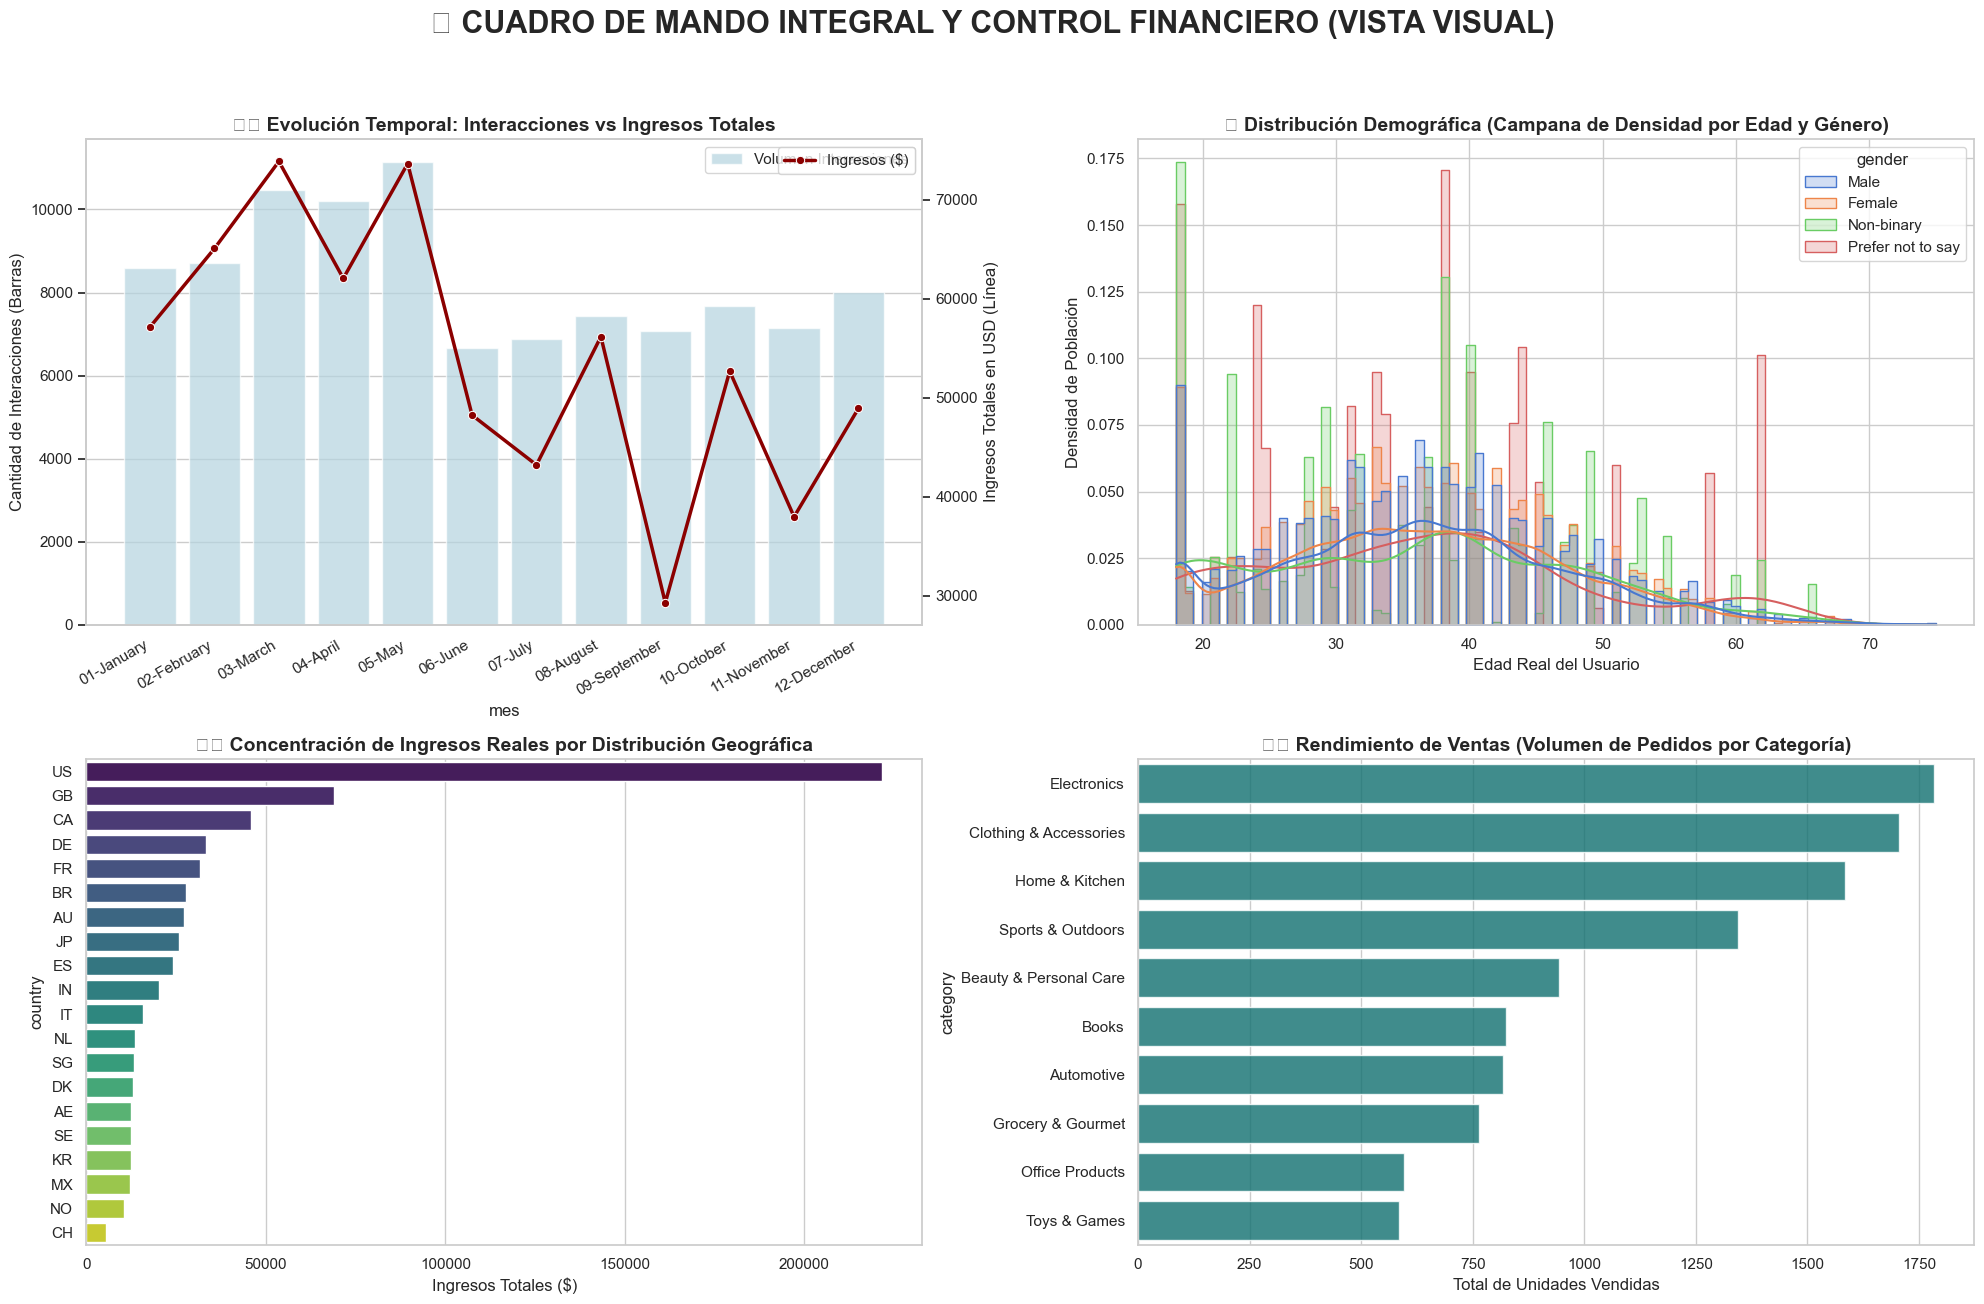


███████████████████████████████████████████████████████████████████████████████████████████████
🌍 CAPA DE CONTROL MACROECONÓMICO DE NEGOCIO (VISTA SATÉLITE)
███████████████████████████████████████████████████████████████████████████████████████████████
 💰 Ingresos Globales de Control : $648,112.74
 🛒 Volumen de Interacciones     : 100,000 registros
 📦 Ventas Efectivas Globales    : 10,950 órdenes
 📈 Tasa de Conversión Base      : 10.95%
 💵 Ticket Medio Efectivo        : $59.19
███████████████████████████████████████████████████████████████████████████████████████████████

📊 REPORT EJECUTIVO: CONCENTRACIÓN FINANCIERA POR PAÍS
               Volumen  Ventas     Ingresos % Ingresos Tasa Conv.
country                                                          
US              37,649   3,908  $221,738.67     34.21%     10.38%
GB               8,886   1,104   $69,090.40     10.66%     12.42%
CA               7,246     750   $45,795.18      7.07%     10.35%
DE               5,439     565   $33

In [16]:
def motor_auditoria_macro_ejecutiva_v2(df_input, col_precio='price', col_target='is_converted', 
                                       col_pais='country', col_categoria='category', 
                                       col_genero='gender', col_edad='age', 
                                       col_fecha='timestamp', n_rangos_edad=5):
    """
    MOTOR AVANZADO DE BI, REPORTING FINANCIERO Y AUDITORÍA DE DATOS v2.
    
    Esta función automatiza la capa de inteligencia de negocio. Extrae métricas macro
    de rendimiento, renderiza cuadros de mando visuales y genera reportes ejecutivos 
    numéricos con filas de control (totales cruzados) sin truncar información en pantalla.
    """
    
    # -----------------------------------------------------------------
    # CONFIGURACIÓN DEFENSIVA DE PANDAS (ELIMINA LOS PUNTOS SUSPENSIVOS "...")
    # -----------------------------------------------------------------
    # Forzamos al entorno de Jupyter a desplegar absolutamente todas las filas y columnas 
    # de los dataframes que imprimamos, anulando el comportamiento de truncado automático.
    pd.set_option('display.max_rows', None)      # Muestra infinitas filas en pantalla
    pd.set_option('display.max_columns', None)   # Muestra infinitas columnas en pantalla
    pd.set_option('display.width', 1000)         # Amplía el ancho del contenedor de texto
    
    # -----------------------------------------------------------------
    # 1. TRATAMIENTO DE DATOS E HIGIENIZACIÓN DE COLUMNAS
    # -----------------------------------------------------------------
    df_bi = df_input.copy()
    
    # Estandarizamos los nombres de las columnas a minúsculas y sin espacios laterales
    # para blindar el código ante cualquier cambio imprevisto en la base de datos.
    df_bi.columns = df_bi.columns.str.strip().str.lower()
    
    # Mapeo sistemático de los parámetros pasados por el analista a minúsculas
    c_precio = col_precio.lower()
    c_target = col_target.lower()
    c_pais = col_pais.lower()
    c_cat = col_categoria.lower()
    c_gen = col_genero.lower()
    c_edad = col_edad.lower()
    c_fecha = col_fecha.lower()
    
    # INYECCIÓN DE LA MÉTRICA REINA: Ingreso Real Efectivo
    # Si 'is_converted' es 1 (True), se multiplica por el precio; si es 0, el ingreso es $0.00.
    df_bi['ingreso_real'] = df_bi[c_precio] * df_bi[c_target].astype(int)
    
    # EXTRACCIÓN DE ATRIBUTOS TEMPORALES CRUCIALES
    df_bi[c_fecha] = pd.to_datetime(df_bi[c_fecha])
    df_bi['año'] = df_bi[c_fecha].dt.year
    # Guardamos el mes con el número por delante (ej: "01-January") para asegurar un orden cronológico perfecto
    df_bi['mes'] = df_bi[c_fecha].dt.strftime('%m-%B')
    
    # CONSTRUCCIÓN DINÁMICA DE RANGOS DE EDAD (PARAMÉTRICO)
    # Buscamos los límites matemáticos reales del set de datos proporcionado
    edad_min, edad_max = df_bi[c_edad].min(), df_bi[c_edad].max()
    # np.linspace crea cortes perfectamente proporcionales desde el mínimo al máximo
    bins_edad = np.linspace(edad_min, edad_max, n_rangos_edad + 1)
    # Construcción de etiquetas ejecutivas claras para las tablas
    labels_edad = [f"De {int(bins_edad[i])} a {int(bins_edad[i+1])} años" for i in range(len(bins_edad)-1)]
    # Asignamos a cada fila su etiqueta demográfica correspondiente
    df_bi['rango_edad'] = pd.cut(df_bi[c_edad], bins=bins_edad, labels=labels_edad, include_lowest=True)
    
    # -----------------------------------------------------------------
    # 2. CÁLCULO DE TOTALES MACRO GLOBALES (MÉTRICAS SATÉLITE)
    # -----------------------------------------------------------------
    # Estas variables almacenan los números maestros contra los que auditedaremos cada tabla posterior
    total_registros_global = len(df_bi)
    total_ventas_global = df_bi[c_target].sum()
    ingreso_total_global = df_bi['ingreso_real'].sum()
    tasa_conversion_global = (total_ventas_global / total_registros_global) * 100
    ticket_medio_global = df_bi[df_bi[c_target] == True][c_precio].mean()
    
    # -----------------------------------------------------------------
    # 3. CAPA VISUAL: PRIMERO LOS GRÁFICOS (DENTRO DEL CUADERNO)
    # -----------------------------------------------------------------
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('📊 CUADRO DE MANDO INTEGRAL Y CONTROL FINANCIERO (VISTA VISUAL)', fontsize=22, weight='bold', y=0.96)
    
    # Gráfico 1: Doble Eje (Evolución Temporal Continua)
    df_mes_grafico = df_bi.groupby('mes').agg(Volumen=(c_target, 'count'), Ingresos=('ingreso_real', 'sum')).reset_index()
    ax1 = axes[0, 0]
    sns.barplot(x='mes', y='Volumen', data=df_mes_grafico, ax=ax1, color='lightblue', alpha=0.7, label='Volumen Interacciones')
    ax1.set_title('⏱️ Evolución Temporal: Interacciones vs Ingresos Totales', fontsize=14, weight='bold')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
    ax1.set_ylabel('Cantidad de Interacciones (Barras)')
    
    ax1_twin = ax1.twinx()
    sns.lineplot(x='mes', y='Ingresos', data=df_mes_grafico, ax=ax1_twin, color='darkred', marker='o', linewidth=2.5, label='Ingresos ($)')
    ax1_twin.set_ylabel('Ingresos Totales en USD (Línea)')
    ax1_twin.grid(False)
    
    # Gráfico 2: Campana de Distribución Demográfica (KDE Cruzado por Género)
    ax2 = axes[0, 1]
    sns.histplot(data=df_bi, x=c_edad, hue=c_gen, kde=True, ax=ax2, element='step', stat='density', common_norm=False, palette='muted')
    ax2.set_title('👥 Distribución Demográfica (Campana de Densidad por Edad y Género)', fontsize=14, weight='bold')
    ax2.set_xlabel('Edad Real del Usuario')
    ax2.set_ylabel('Densidad de Población')
    
    # Gráfico 3: Concentración de Ingresos por País (Pareto Ordenado)
    ax3 = axes[1, 0]
    df_pais_geo = df_bi.groupby(c_pais)['ingreso_real'].sum().sort_values(ascending=False).reset_index()
    sns.barplot(x='ingreso_real', y=c_pais, data=df_pais_geo, ax=ax3, palette='viridis')
    ax3.set_title('🗺️ Concentración de Ingresos Reales por Distribución Geográfica', fontsize=14, weight='bold')
    ax3.set_xlabel('Ingresos Totales ($)')
    
    # Gráfico 4: Rendimiento Comercial y Eficiencia por Categoría
    ax4 = axes[1, 1]
    df_cat_geo = df_bi.groupby(c_cat).agg(Ventas=(c_target, 'sum')).sort_values(by='Ventas', ascending=False).reset_index()
    sns.barplot(x='Ventas', y=c_cat, data=df_cat_geo, ax=ax4, color='teal', alpha=0.8)
    ax4.set_title('🏷️ Rendimiento de Ventas (Volumen de Pedidos por Categoría)', fontsize=14, weight='bold')
    ax4.set_xlabel('Total de Unidades Vendidas')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()  # Renderiza el tablero de control de manera inmediata
    
    # -----------------------------------------------------------------
    # 4. CAPA EJECUTIVA: REPORTES ESTRUCTURADOS CON FILAS DE TOTALES REALES
    # -----------------------------------------------------------------
    
    def formatear_y_añadir_totales(df_agrupado, nombre_seccion):
        """
        Función auxiliar interna. Toma un bloque analítico, calcula proporciones globales,
        aplica máscaras estéticas de finanzas ($, comas, %) e inyecta la fila de control
        TOTAL SECCIÓN para asegurar cuadres matemáticos perfectos.
        """
        # Extraemos los agregados puros del dataframe actual
        sum_vol = df_agrupado['Volumen Actividad'].sum()
        sum_ven = df_agrupado['Ventas Totales'].sum()
        sum_ing = df_agrupado['Ingresos Totales'].sum()
        
        # Calculamos los indicadores macro basados en los totales exactos calculados
        pct_ing_final = (sum_ing / ingreso_total_global) * 100
        cr_final = (sum_ven / sum_vol) * 100
        
        # Creamos una copia de trabajo para estructurar los porcentajes flotantes
        df_reporte = df_agrupado.copy()
        df_reporte['% Ingresos Global'] = (df_reporte['Ingresos Totales'] / ingreso_total_global) * 100
        df_reporte['Tasa Conversión'] = (df_reporte['Ventas Totales'] / df_reporte['Volumen Actividad']) * 100
        
        # CONSTRUCCIÓN DE LA TABLA DE TEXTO FORMATEADA PARA AUDITORÍA
        df_format = pd.DataFrame(index=df_reporte.index)
        df_format['Volumen'] = df_reporte['Volumen Actividad'].map('{:,}'.format)
        df_format['Ventas'] = df_reporte['Ventas Totales'].map('{:,}'.format)
        df_format['Ingresos'] = df_reporte['Ingresos Totales'].map('${:,.2f}'.format)
        df_format['% Ingresos'] = df_reporte['% Ingresos Global'].map('{:.2f}%'.format)
        df_format['Tasa Conv.'] = df_reporte['Tasa Conversión'].map('{:.2f}%'.format)
        
        # INYECCIÓN IMPERATIVA DE LA FILA DE CIERRE GLOBAL
        df_format.loc['TOTAL SECCIÓN'] = [
            f"{sum_vol:,}", f"{sum_ven:,}", f"${sum_ing:,.2f}", f"{pct_ing_final:.2f}%", f"{cr_final:.2f}%"
        ]
        
        print("\n" + "="*95)
        print(f"📊 REPORT EJECUTIVO: {nombre_seccion}")
        print("="*95)
        print(df_format.to_string())
        print("="*95)
        return df_reporte

    # IMPRESIÓN DE LA MARQUESINA DE CONTROL MACRO (LA VERDAD DEL NEGOCIO)
    print("\n" + "█"*95)
    print("🌍 CAPA DE CONTROL MACROECONÓMICO DE NEGOCIO (VISTA SATÉLITE)")
    print("█"*95)
    print(f" 💰 Ingresos Globales de Control : ${ingreso_total_global:,.2f}")
    print(f" 🛒 Volumen de Interacciones     : {total_registros_global:,} registros")
    print(f" 📦 Ventas Efectivas Globales    : {total_ventas_global:,} órdenes")
    print(f" 📈 Tasa de Conversión Base      : {tasa_conversion_global:.2f}%")
    print(f" 💵 Ticket Medio Efectivo        : ${ticket_medio_global:.2f}")
    print("█"*95)

    # 🗺️ REPORT 1: Distribución Geográfica por País
    df_pais = df_bi.groupby(c_pais).agg(
        **{'Volumen Actividad': (c_target, 'count'), 'Ventas Totales': (c_target, 'sum'), 'Ingresos Totales': ('ingreso_real', 'sum')}
    ).sort_values(by='Ingresos Totales', ascending=False)
    formatear_y_añadir_totales(df_pais, "CONCENTRACIÓN FINANCIERA POR PAÍS")

    # 🏷️ REPORT 2: Rendimiento Comercial por Categoría
    df_cat = df_bi.groupby(c_cat).agg(
        **{'Volumen Actividad': (c_target, 'count'), 'Ventas Totales': (c_target, 'sum'), 'Ingresos Totales': ('ingreso_real', 'sum')}
    ).sort_values(by='Ingresos Totales', ascending=False)
    formatear_y_añadir_totales(df_cat, "RENDIMIENTO FINANCIERO POR CATEGORÍA")

    # ⏱️ REPORT 3: Evolución Temporal Completa (Año, Mes) - SIN TRUNCAR
    # Agrupamos jerárquicamente por Año y Mes para mostrar la evolución exacta de la caja
    df_tiempo = df_bi.groupby(['año', 'mes']).agg(
        **{'Volumen Actividad': (c_target, 'count'), 'Ventas Totales': (c_target, 'sum'), 'Ingresos Totales': ('ingreso_real', 'sum')}
    ).sort_values(by=['año', 'mes'], ascending=True)
    formatear_y_añadir_totales(df_tiempo, "EVOLUCIÓN TEMPORAL DE VENTAS E INGRESOS (HISTÓRICO COMPLETO)")

    # 👥 REPORT 4: Segmentación Demográfica por Rangos de Edad (Dinámico)
    df_edad_rep = df_bi.groupby('rango_edad', observed=False).agg(
        **{'Volumen Actividad': (c_target, 'count'), 'Ventas Totales': (c_target, 'sum'), 'Ingresos Totales': ('ingreso_real', 'sum')}
    )
    formatear_y_añadir_totales(df_edad_rep, f"ANÁLISIS DEMOGRÁFICO POR EDAD (Segmentado en {n_rangos_edad} Rangos)")

    # ⚧️ REPORT 5: Segmentación por Género
    df_gen_rep = df_bi.groupby(c_gen).agg(
        **{'Volumen Actividad': (c_target, 'count'), 'Ventas Totales': (c_target, 'sum'), 'Ingresos Totales': ('ingreso_real', 'sum')}
    ).sort_values(by='Ingresos Totales', ascending=False)
    formatear_y_añadir_totales(df_gen_rep, "ANÁLISIS DE VENTAS POR GÉNERO")

    # Restablecemos las opciones predeterminadas de Pandas por buena práctica de ingeniería de software
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')

    return df_bi

# -----------------------------------------------------------------
# EJECUCIÓN DEL MOTOR DE BI v2
# -----------------------------------------------------------------
# Al ejecutar esta línea, Pandas desplegará el historial temporal completo en tu pantalla sin cortes.
df_analytics_master = motor_auditoria_macro_ejecutiva_v2(
    df_input=df_maestro, 
    n_rangos_edad=5
)

🎯 El Diagnóstico Basado en Hechos: ¿Dónde está el dinero?
Si analizamos con lupa los reportes anteriores, emergen tres realidades incontestables que exigen una intervención micro-analítica urgente:

* La paradoja del volumen frente a la eficiencia (El caso de EE. UU. y el Reino Unido):

- Hecho: Estados Unidos (US) es nuestro gigante macro, aportando el 34.21% de los ingresos globales ($221,738.67) con 37,649 interacciones. Sin embargo, su tasa de conversión es de apenas el 10.38% (por debajo de la media global de 10.95%).

- Hecho: El Reino Unido (GB) inyecta $69,090.40 (10.66% del ingreso) con solo 8,886 interacciones, logrando una conversión espectacular del 12.42%.

Conclusión Directa: Si logramos que el micro-embudo de EE. UU. emule la eficiencia de conversión del Reino Unido (subir del 10.38% al 12.42%), capturaríamos de inmediato miles de dólares en ingresos marginales sin gastar un solo céntimo más en marketing o captación de tráfico.

* La mina de oro demográfica latente (El grupo de más de 63 años):

- Hecho: El rango de 63 a 75 años es estadísticamente irrelevante en volumen (solo 743 registros, el 0.84% del negocio).

- Hecho: Sorprendentemente, este grupo registra la tasa de conversión más alta de toda la compañía: un 13.86%. El cliente senior interactúa poco, pero cuando lo hace, compra de forma masiva.

* El sesgo de facturación por categoría (Electrónica vs. Belleza):

- Hecho: Electronics sostiene el negocio con el 36.48% de los ingresos ($236,412.34) con una conversión normal del 10.67%.

- Hecho: Beauty & Personal Care representa solo el 4.06% del ingreso, pero su conversión micro es del 12.53%. Hay una tracción comercial en categorías secundarias que está desaprovechada por falta de stock o exposición.

## 🚀 Análisis de Micro-Embudo Segmentado (Matriz de Conversión)

El paso vital y definitivo que debemos dar de inmediato es cruzar la Capa Macroeconómica con la Micro-Eficiencia Operativa. Dejaremos de mirar variables aisladas para analizar la intersección de los datos.

In [19]:
# DEFINICIÓN DE LA FUNCIÓN PRINCIPAL
# Recibe como argumento 'df_input', que es el DataFrame con los datos macro ya procesados.
def analisis_micro_embudo_estrategico(df_input):
    """
    CAPA EJECUTIVA DE MICRO-ANÁLISIS DE EMBUDO.
    Cruza variables macro (País, Categoría) con micro-comportamiento (Conversión y Ticket Medio)
    para descubrir palancas de optimización inmediata de ingresos.
    """
    # CONFIGURACIÓN DE VISUALIZACIÓN EN JUPYTER
    # Evita que Pandas recorte las filas horizontalmente si el reporte es muy largo.
    pd.set_option('display.max_rows', None)
    # Define el ancho máximo de la pantalla en 1000 caracteres para que las tablas no se deformen.
    pd.set_option('display.width', 1000)
    
    # COPIA SEGURA DE DATOS Y ESTANDARIZACIÓN
    # Creamos una copia idéntica del DataFrame para trabajar sin alterar los datos originales.
    df_micro = df_input.copy()
    # Limpiamos los nombres de las columnas quitando espacios (.strip()) y pasándolas a minúsculas (.lower()).
    df_micro.columns = df_micro.columns.str.strip().str.lower()
    
    # CÁLCULO DEL INGRESO REAL EFECTIVO
    # Creamos la columna 'ingreso_real' multiplicando el precio por la conversión (True=1, False=0).
    # Si compró, guarda el precio; si no compró, guarda automáticamente 0.
    df_micro['ingreso_real'] = df_micro['price'] * df_micro['is_converted'].astype(int)
    
    # IMPRESIÓN DE LA CABECERA ESTÉTICA
    print("\n" + "█"*95)
    print("🚀 EJECUCIÓN DE MICRO-AUDITORÍA: CRUCE MATRICIAL PAÍS X CATEGORÍA")
    print("█"*95)
    
    # -----------------------------------------------------------------
    # PALANCA 1: MATRIZ DE EFICIENCIA GEOGRÁFICA Y DE PRODUCTO
    # -----------------------------------------------------------------
    # AGRUPACIÓN MULTIVARIABLE (PAÍS + CATEGORÍA)
    # Agrupamos por país y categoría a la vez, y calculamos con '.agg' tres métricas fundamentales:
    # 'Volumen' (total de visitas), 'Ventas' (total de compras reales) e 'Ingresos' (dinero real generado).
    # '.reset_index()' aplana el resultado para volver a tener un DataFrame tradicional y limpio.
    micro_pais_cat = df_micro.groupby(['country', 'category']).agg(
        Volumen=('is_converted', 'count'),
        Ventas=('is_converted', 'sum'),
        Ingresos=('ingreso_real', 'sum')
    ).reset_index()
    
    # CÁLCULO DE RATIOS MICRO DE RENDIMIENTO
    # Calculamos el porcentaje de conversión de cada nicho: (Ventas / Volumen) * 100.
    micro_pais_cat['Tasa_Conv'] = (micro_pais_cat['Ventas'] / micro_pais_cat['Volumen']) * 100
    # Calculamos el ticket medio dividiendo los ingresos entre las ventas.
    # '.replace(0, np.nan)' evita el error matemático de dividir por cero en nichos donde no hubo ventas.
    micro_pais_cat['Ticket_Medio'] = micro_pais_cat['Ingresos'] / micro_pais_cat['Ventas'].replace(0, np.nan)
    
    # ORDENACIÓN ESTRATÉGICA EJECUTIVA
    # Ordenamos de mayor a menor según el Volumen de tráfico recibido ('ascending=False'),
    # y en caso de empate, de menor a mayor conversión ('ascending=True') para detectar ineficiencias.
    micro_pais_cat = micro_pais_cat.sort_values(by=['Volumen', 'Tasa_Conv'], ascending=[False, True])
    
    # CREACIÓN DEL REPORTE VISUAL 1
    # Creamos un DataFrame vacío usando los mismos índices ordenados de la matriz anterior.
    df_reporte_1 = pd.DataFrame(index=micro_pais_cat.index)
    # Asignamos las columnas correspondientes de país y categoría.
    df_reporte_1['País'] = micro_pais_cat['country']
    df_reporte_1['Categoría'] = micro_pais_cat['category']
    # Aplicamos formatos de lectura ejecutiva: separadores de miles, signos de dólar y porcentajes con 2 decimales.
    df_reporte_1['Volumen (Tráfico)'] = micro_pais_cat['Volumen'].map('{:,}'.format)
    df_reporte_1['Ventas (Órdenes)'] = micro_pais_cat['Ventas'].map('{:,}'.format)
    df_reporte_1['Tasa Conv. Micro'] = micro_pais_cat['Tasa_Conv'].map('{:.2f}%'.format)
    df_reporte_1['Ingresos Generados'] = micro_pais_cat['Ingresos'].map('${:,.2f}'.format)
    
    # IMPRESIÓN EN PANTALLA DE LA TABLA 1
    print("\n📌 TABLA 1: OPORTUNIDADES DE EMBUDO POR PAÍS Y CATEGORÍA (Top 25 interacciones)")
    # Muestra las primeras 25 filas del reporte formateado sin mostrar los índices numéricos de la izquierda.
    print(df_reporte_1.head(25).to_string(index=False))
    print("-" * 95)
    
    # -----------------------------------------------------------------
    # PALANCA 2: EL "SWEET SPOT" DEMOGRÁFICO DE ALTA CONVERSIÓN
    # -----------------------------------------------------------------
    # IMPRESIÓN DE LA CABECERA DE LA TABLA 2
    print("\n📌 TABLA 2: MICRO-EMBUDO POR RANGO DE EDAD Y CATEGORÍA DE PRODUCTO")
    
    # AGRUPACIÓN MULTIVARIABLE (RANGO DE EDAD + CATEGORÍA)
    # Agrupamos por los 5 rangos de edad y por las categorías. 'observed=False' obliga a mantener la estructura fija.
    # Extraemos el volumen de tráfico, las ventas totales y los ingresos generados para cada perfil de edad.
    micro_edad_cat = df_micro.groupby(['rango_edad', 'category'], observed=False).agg(
        Volumen=('is_converted', 'count'),
        Ventas=('is_converted', 'sum'),
        Ingresos=('ingreso_real', 'sum')
    ).reset_index()
    
    # CÁLCULO DE RATIO Y ORDENACIÓN DE LA TABLA 2
    # Calculamos la tasa de conversión para saber qué porcentaje de usuarios de cada edad terminan comprando.
    micro_edad_cat['Tasa_Conv'] = (micro_edad_cat['Ventas'] / micro_edad_cat['Volumen']) * 100
    # Ordenamos toda la matriz de mayor a menor tasa de conversión para ver los nichos más rentables ("Sweet Spots").
    micro_edad_cat = micro_edad_cat.sort_values(by='Tasa_Conv', ascending=False)
    
    # CREACIÓN DEL REPORTE VISUAL 2
    # Inicializamos el segundo DataFrame para la presentación ejecutiva basado en los índices ordenados de edad.
    df_reporte_2 = pd.DataFrame(index=micro_edad_cat.index)
    df_reporte_2['Rango Edad'] = micro_edad_cat['rango_edad']
    df_reporte_2['Categoría'] = micro_edad_cat['category']
    # Aplicamos las funciones de mapeo de texto para dar formato limpio a los números, porcentajes y divisas.
    df_reporte_2['Volumen'] = micro_edad_cat['Volumen'].map('{:,}'.format)
    df_reporte_2['Tasa Conv.'] = micro_edad_cat['Tasa_Conv'].map('{:.2f}%'.format)
    df_reporte_2['Ingresos'] = micro_edad_cat['Ingresos'].map('${:,.2f}'.format)
    
    # IMPRESIÓN EN PANTALLA DE LA TABLA 2
    # Imprime los 15 nichos demográficos más eficientes del negocio para la toma de decisiones.
    print(df_reporte_2.head(15).to_string(index=False))
    print("█"*95)
    
    # RESTABLECIMIENTO DEL ENTORNO DE PANDAS
    # Devolvemos los parámetros de visualización de Jupyter a su estado original por buenas prácticas de rendimiento.
    pd.reset_option('display.max_rows')
    pd.reset_option('display.width')
    
    # RETORNO DE RESULTADOS
    # La función devuelve los dos DataFrames crudos con sus cálculos para poder usarlos en gráficos o exportaciones posteriores.
    return micro_pais_cat, micro_edad_cat

# =====================================================================
# EJECUCIÓN DEL MICRO-CRUCE ANALÍTICO
# =====================================================================
# Ejecuta la función pasándole tu DataFrame maestro anterior ('df_analytics_master')
# Guarda los DataFrames resultantes en 'df_micro_pais_cat' y 'df_micro_edad_cat' respectivamente.
df_micro_pais_cat, df_micro_edad_cat = analisis_micro_embudo_estrategico(df_analytics_master)


███████████████████████████████████████████████████████████████████████████████████████████████
🚀 EJECUCIÓN DE MICRO-AUDITORÍA: CRUCE MATRICIAL PAÍS X CATEGORÍA
███████████████████████████████████████████████████████████████████████████████████████████████

📌 TABLA 1: OPORTUNIDADES DE EMBUDO POR PAÍS Y CATEGORÍA (Top 25 interacciones)
País              Categoría Volumen (Tráfico) Ventas (Órdenes) Tasa Conv. Micro Ingresos Generados
  US            Electronics             5,930              558            9.41%         $72,664.14
  US         Home & Kitchen             5,611              592           10.55%         $30,810.49
  US Clothing & Accessories             5,502              610           11.09%         $25,200.49
  US      Sports & Outdoors             4,731              536           11.33%         $37,283.53
  US                  Books             3,453              264            7.65%          $6,805.20
  US             Automotive             2,969              291      

🧭 Bloque 1: El Alma del Negocio — ¿Qué es la Tasa de Conversión y para qué sirve?
- En el mundo del comercio (tanto físico como digital), la métrica reina no es el tráfico, ni los clics, ni el volumen de usuarios. 

* La reina absoluta es la Tasa de Conversión (CR o Conversion Rate).
- ¿Qué es exactamente?
Imaginemos que eres el dueño de una tienda física de electrónica en la Gran Vía de Madrid. A lo largo del día, entran por la puerta 100 personas (eso es tu Volumen de Actividad o Tráfico). De esas 100 personas que miran las estanterías, entran al probador o preguntan precios, solo 11 personas pasan por la caja, sacan la tarjeta y compran un producto (eso son tus Ventas Efectivas).

- La Tasa de Conversión es el porcentaje de personas que realizan la acción que deseamos (comprar) respecto al total de personas que entraron a interactuar en la web.

- ¿Cómo se calcula matemáticamente?
* La fórmula es una regla de tres simple, pero con un poder inmenso:

Tasa de Conversión = Ventas Efectivas / Volumen Total de Interacciones x 100

- Si aplicamos los números de nuestro reporte global:

- Ventas efectivas globales = 10,950 órdenes 
- Volumen total de interacciones = 100,000 registros
* Tasa de Conversión Global = ( 10,950 / 100,000) x 100 = 10.95%
¿Para qué sirve estratégicamente?
Sirve para medir la eficiencia operativa y la salud de tu embudo de ventas.
Si tu Tasa de Conversión es alta, significa que tu producto es atractivo, tu precio es adecuado, tu plataforma es fácil de usar y estás atrayendo al público correcto.
Si tu Tasa de Conversión es baja, tienes una fuga en el embudo: estás gastando dinero en atraer gente a la tienda, pero la gente se va con las manos vacías (puede ser porque el proceso de pago es complicado, los precios son altos o el producto no convence).

🛠️ Bloque 2: Anatomía Quirúrgica del Script — ¿Qué hicimos línea a línea?
Vamos a explicar la magia técnica que ocurre detrás de los comandos de Python que ejecutamos en Jupyter. El script hace tres cosas esenciales: limpiar, cruzar y formatear.

1. El Control de Pantalla y Limpieza Basal: 

- pd.set_option('display.max_rows', None)
- df_micro = df_input.copy()
- df_micro.columns = df_micro.columns.str.strip().str.lower()

¿Para qué sirve? Jupyter, por defecto, es "perezoso" y esconde los datos largos. Con set_option le rompemos las cadenas para que nos muestre todo. Luego hacemos una copia segura para no destruir los datos originales y estandarizamos las columnas a minúsculas para que Python no se confunda entre "País", "pais" o "PAÍS".

2. El Truco del "Interruptor Binario" Financiero:

df_micro['ingreso_real'] = df_micro['price'] * df_micro['is_converted'].astype(int)

- ¿Qué hace? Esto es pura poesía matemática. La columna is_converted contiene valores lógicos (True si compró, False si no). Al transformarla con .astype(int), convertimos los True en 1 y los False en 0.

- ¿Para qué sirve? Al multiplicar el precio por ese 1 o 0, logramos que si un usuario no compró, su ingreso se convierta en $0.00 de forma automática. Así, cuando sumemos los ingresos por país, la máquina solo sumará el dinero de las ventas reales, ignorando a los usuarios que solo miraron

3. El Corazón del Micro-Análisis: La Agrupación Multivariable (groupby)

micro_pais_cat = df_micro.groupby(['country', 'category']).agg(...)

- ¿Qué hace? Aquí es donde pasamos de la vista satélite (Macro) a la vista microscópica (Micro). En lugar de mirar "Estados Unidos" por un lado y "Electrónica" por otro, le pedimos a Python que haga subgrupos específicos: "Júntame a todos los usuarios que sean de EE. UU. Y ADEMÁS hayan interactuado con Electrónica".

- ¿Para qué sirve? Al calcular el volumen, las ventas y la tasa de conversión para cada micro-nicho, podemos ver con precisión láser en qué combinación exacta de producto y país estamos ganando o perdiendo dinero.

4. La Protección Matemática (replace(0, np.nan))

micro_pais_cat['Ticket_Medio'] = micro_pais_cat['Ingresos'] / micro_pais_cat['Ventas'].replace(0, np.nan)

Qué hace? En matemáticas, dividir cualquier número entre cero hace que el universo colapse (genera un error que detiene el script). Si en algún país lejano tuvimos 50 visitas en una categoría pero 0 ventas, al calcular el ticket medio estaríamos dividiendo los ingresos ($0) entre las ventas (0). Al reemplazar el 0 por un valor nulo (NaN), Python simplemente ignora el cálculo y el script sigue corriendo felizmente.

📈 Bloque 3: ¿Qué nos conllevó todo este análisis? (Los Descubrimientos)
Hacer este análisis nos conllevó pasar de la intuición a los hechos comprobados. Nos permitió descubrir anomalías y oportunidades ocultas que a simple vista nadie vería:

Descubrimos que el tamaño no lo es todo: EE. UU. nos da mucho volumen (tráfico masivo), pero es ineficiente convirtiendo (10.38%). El Reino Unido, con cuatro veces menos tráfico, es una máquina de conversión ultra-eficiente (12.42%).

Descubrimos "Minas de Oro" Demográficas: Los usuarios de 63 a 75 años representan un suspiro en el tráfico global, pero cuando entran a la web, compran con una efectividad brutal (13.86%).

Descubrimos Desequilibrios de Categoría: Electronics genera la mayor parte del dinero, pero categorías más pequeñas como Beauty & Personal Care tienen un porcentaje de conversión micro mucho más alto (12.53%).

🎯 Bloque 4: ¿Para qué se hizo? (La Visión de Negocio)
EL código sirvió para tomar decisiones que impacten en el balance financiero de la empresa. Todo este esfuerzo se hizo para tres objetivos estratégicos vitales:

* Dejar de tirar el dinero en publicidad: Si sabemos que el grupo de más de 63 años convierte al 13.86%, reorientaremos el presupuesto de marketing para buscar a más clientes de ese perfil. Cada euro invertido ahí dará más rendimiento que invertirlo en un grupo que convierte menos.

* Reparar las fugas del embudo (UX/UI): Si la Tabla 1 de nuestro script revela que una categoría clave en un país específico tiene miles de visitas pero una conversión de apenas el 7%, tenemos una alarma roja. El equipo de desarrollo debe ir a revisar si esa página web carga lento, si los precios locales están mal calculados o si las tarjetas de crédito de ese país están siendo rechazadas.

* Optimización de Inventario y Stock: Si vemos que una categoría secundaria tiene una conversión micro espectacular en España, la orden para el departamento de compras es clara: "Traed más stock de ese producto y ponedlo en la página principal, porque la gente lo está buscando y lo compra con los ojos cerrados".

Una vez que las tablas y el código han hablado, nuestra libreta de programación se cierra y se abre nuestra agenda de estrategia corporativa. Los datos sin acción son solo ruido.

Nuestro rol ahora es transformar esos hallazgos en órdenes ejecutivas claras para los departamentos de Marketing, Producto (UX/UI), Operaciones y Finanzas.

Para aprovechar los nichos de alta conversión (Sweet Spots) y tapar las fugas de dinero (Agujeros Negros), debemos activar un Plan de Choque Operativo dividido en cuatro frentes estratégicos inmediatos:

1. Plan de Captación de Alta Eficiencia (Aprovechar Oportunidades)
Los datos nos dicen que hay perfiles (como el segmento senior de 63 a 75 años o la categoría de Beauty & Personal Care) que compran con una facilidad pasmosa, pero tienen muy poco volumen de tráfico.

* Acción Inmediata (Reunión con Marketing Digital): Ordenar una reasignación presupuestaria de campañas (Paid Media). Si estamos gastando el 80% del presupuesto de anuncios en captar público joven en canales saturados, vamos a desviar un 15% o 20% de ese capital de forma quirúrgica hacia campañas específicas para el público senior en plataformas que ellos utilicen con asiduidad (por ejemplo, Facebook Ads enfocado en intereses de hogar, cocina o lectura).

* Venta Cruzada Inteligente (Cross-Selling): Como ya sabemos qué categorías prefiere este perfil, configuraremos el motor de recomendaciones de la web para que, en cuanto un usuario de ese rango de edad inicie sesión, la portada se personalice automáticamente destacando productos de Home & Kitchen o Books.

2. Auditoría Quirúrgica del Checkout (Tapar Fugas en EE. UU.)
EE. UU. es nuestro motor de ingresos, pero su conversión (10.38%) está por debajo de la media global. Al ser un mercado tan masivo, cada décima de porcentaje que se pierde son miles de dólares evaporados.

* Acción Inmediata (Reunión con Producto y UX/UI): Implementar un análisis de Micro-Embudo de Comportamiento en la web de EE. UU. Necesitamos monitorizar el comportamiento del usuario mediante herramientas de mapas de calor o eventos de analítica digital para responder a tres preguntas:

* ¿Los usuarios añaden el producto al carrito pero huyen en la pantalla de pago? (Posible fricción con gastos de envío sorpresa o falta de métodos de pago locales como Apple Pay o Venmo).

* ¿La página de Electronics tarda más de 3 segundos en cargar en servidores americanos? (Fuga por rendimiento técnico).

* Implementación de un Plan de Recuperación: Activar de inmediato campañas automatizadas de email marketing para carritos abandonados con un pequeño incentivo (como envío gratuito o un 5% de descuento exclusivo para el mercado estadounidense) para recuperar al usuario indeciso antes de 24 horas.

3. Optimización del Ticket Medio (Maximizar el Valor del Cliente)
La matriz cruzada nos desvelará qué combinaciones tienen una conversión excelente pero un ticket medio bajo (mucha gente compra, pero gastan poco).

- Estrategia de Bundling (Paquetes de Productos): Si en países como España o Brasil vemos que la categoría Beauty convierte muy bien pero el ticket medio es bajo, diseñaremos "packs ejecutivos" (por ejemplo: Crema hidratante + Sérum + Contorno) a un precio ligeramente rebajado en conjunto. Elevamos el valor del carrito de forma artificial aprovechando la alta predisposición de compra de ese usuario.

- Umbrales de Envío Gratuito Dinámicos: Si el ticket medio efectivo global es de $59.19, colocaremos estratégicamente el umbral de envío gratuito en los $69.00. Esto empuja psicológicamente al comprador a añadir un producto secundario de bajo coste (como algo de la categoría Grocery u Office) para ahorrarse el coste de envío, aumentando el beneficio neto por transacción.

4. Gobernanza de Datos y Cuadros de Mando en Tiempo Real
Como directores, no podemos esperar a final de mes para ver si estas medidas están funcionando. Necesitamos monitorización continua.

- Creación de un Dashboard de Alertas Tempranas: Programar un cuadro de mando ejecutivo (en Power BI o Streamlit) conectado directamente a nuestra base de datos. Este tablero no mostrará tablas infinitas, sino alertas visuales automatizadas KPI:

- Si la conversión en EE. UU. baja del 10%, el indicador se pone en rojo y envía una alerta automática al equipo técnico.

- Si el tráfico senior sube un 50% gracias a las nuevas campañas, el indicador se pone en verde y calcula el retorno de la inversión publicitaria en tiempo real.

## 📈 Análisis Del Comportamiento del Consumidor (Análisis del Embudo y Dispositivos)

--> Generando visualizaciones del comportamiento del consumidor...


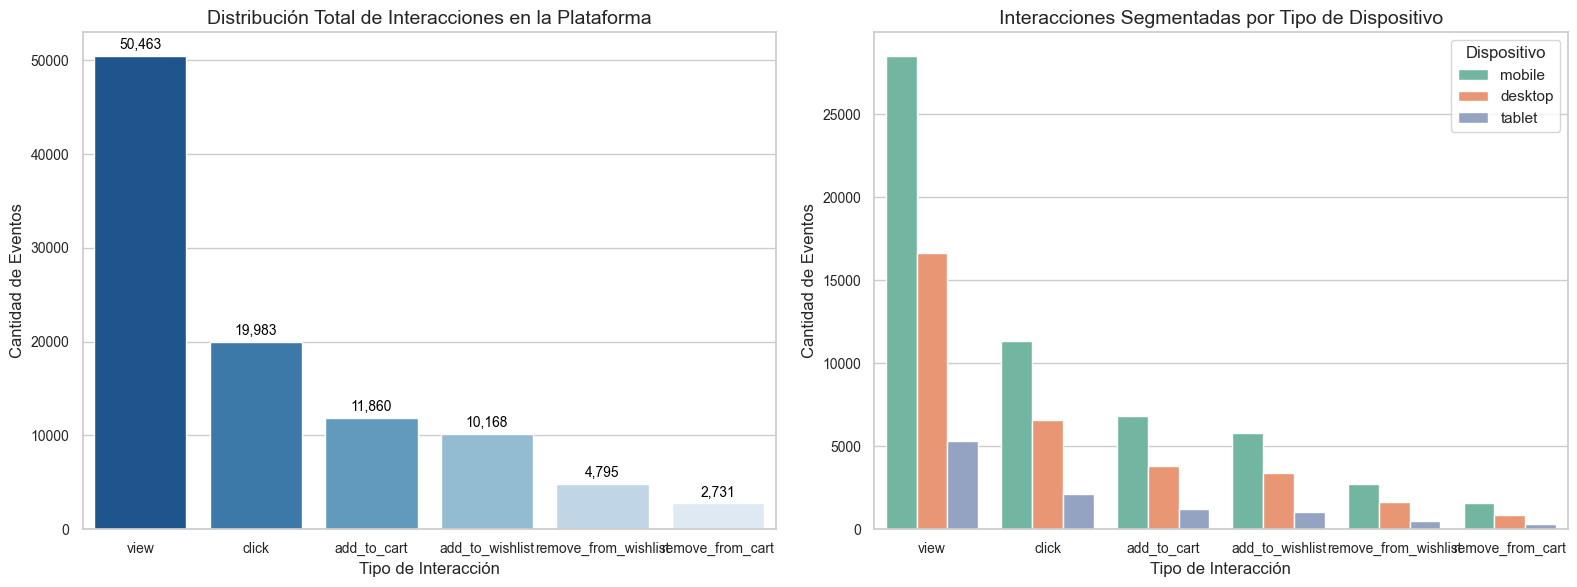


💡 NOTAS DE ANÁLISIS EJECUTIVO (KPIs):
Total de registros analizados: 100,000
Dominancia de interacción:
interaction_type
view                   50.46
click                  19.98
add_to_cart            11.86
add_to_wishlist        10.17
remove_from_wishlist    4.79
remove_from_cart        2.73
Name: proportion, dtype: float64


In [14]:
# ==============================================================================
# PROYECTO FINAL: INTELIGENCIA DE PRODUCTO E-COMMERCE
# Fase: 4.1. EDA Visual - Comportamiento por Tipo de Interacción y Dispositivo
# Objetivo: Identificar los puntos calientes de interacción en la plataforma
# ==============================================================================

print("--> Generando visualizaciones del comportamiento del consumidor...")

# Creamos una figura con dos subgráficos (1 fila, 2 columnas) para optimizar el espacio del reporte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 🛠️ Gráfico 1: Distribución Absoluta de Tipos de Interacción
sns.countplot(
    data=df_maestro, 
    x='interaction_type', 
    order=df_maestro['interaction_type'].value_counts().index,
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Distribución Total de Interacciones en la Plataforma')
axes[0].set_xlabel('Tipo de Interacción')
axes[0].set_ylabel('Cantidad de Eventos')

# Añadir etiquetas de datos encima de cada barra para mayor profesionalismo
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                     textcoords='offset points')

# 🛠️ Gráfico 2: Interacciones segmentadas por Tipo de Dispositivo (Móvil vs PC, etc.)
sns.countplot(
    data=df_maestro, 
    x='interaction_type', 
    hue='device_type',
    order=df_maestro['interaction_type'].value_counts().index,
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Interacciones Segmentadas por Tipo de Dispositivo')
axes[1].set_xlabel('Tipo de Interacción')
axes[1].set_ylabel('Cantidad de Eventos')
axes[1].legend(title='Dispositivo', loc='upper right')

plt.tight_layout()
plt.show()

# Conclusiones automatizadas en texto para dejar registro en el notebook
print("\n💡 NOTAS DE ANÁLISIS EJECUTIVO (KPIs):")
print(f"Total de registros analizados: {len(df_maestro):,}")
print("Dominancia de interacción:")
print(df_maestro['interaction_type'].value_counts(normalize=True) * 100)

## ⏱️ Análisis del Factor Tiempo (Análisis de Retención/Dwell Time)

--> Analizando métricas de tiempo de retención por categoría...


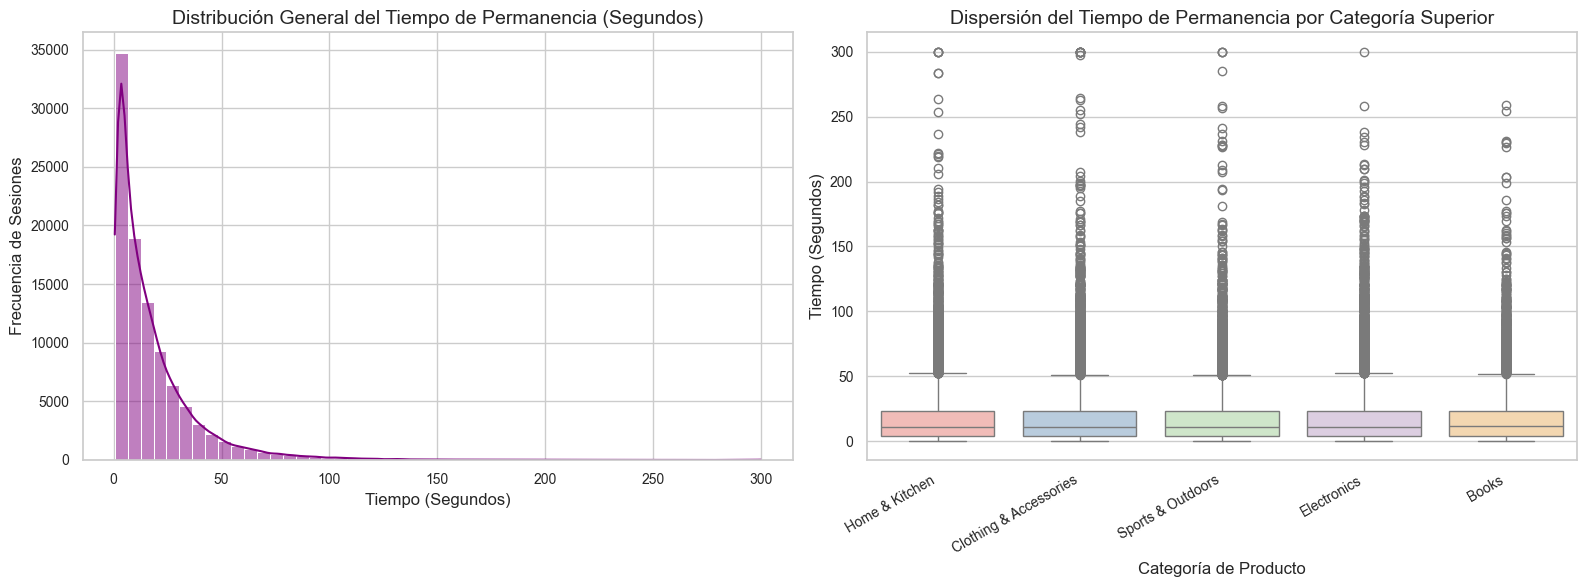


📊 ESTADÍSTICOS DESCRIPTIVOS DEL TIEMPO DE PERMANENCIA (Segundos):


count   100000.00
mean        17.94
std         21.56
min          0.50
25%          4.26
50%         11.15
75%         23.34
max        300.00
Name: dwell_time_secs, dtype: float64

In [15]:
# ==============================================================================
# PROYECTO FINAL: INTELIGENCIA DE PRODUCTO E-COMMERCE
# Fase: 4.2. EDA Visual - Análisis del Tiempo de Permanencia (Dwell Time)
# Objetivo: Detectar qué categorías de productos retienen más la atención del cliente
# ==============================================================================

print("--> Analizando métricas de tiempo de retención por categoría...")

# Convertimos los milisegundos a segundos para que la lectura del gráfico sea más humana y ejecutiva
df_maestro['dwell_time_secs'] = df_maestro['dwell_time_ms'] / 1000.0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 🛠️ Gráfico 1: Histograma y Densidad General del Tiempo en Segundos
sns.histplot(
    data=df_maestro, 
    x='dwell_time_secs', 
    kde=True, 
    ax=axes[0], 
    color='purple',
    bins=50
)
axes[0].set_title('Distribución General del Tiempo de Permanencia (Segundos)')
axes[0].set_xlabel('Tiempo (Segundos)')
axes[0].set_ylabel('Frecuencia de Sesiones')

# 🛠️ Gráfico 2: Boxplot para comparar la distribución por Categorías Principales
# Nota de profesor: El boxplot es clave para que los reclutadores vean que sabes detectar outliers visualmente
top_categories = df_maestro['category'].value_counts().head(5).index
df_filtrado_cat = df_maestro[df_maestro['category'].isin(top_categories)]

sns.boxplot(
    data=df_filtrado_cat, 
    x='category', 
    y='dwell_time_secs', 
    ax=axes[1], 
    palette='Pastel1'
)
axes[1].set_title('Dispersión del Tiempo de Permanencia por Categoría Superior')
axes[1].set_xlabel('Categoría de Producto')
axes[1].set_ylabel('Tiempo (Segundos)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print("\n📊 ESTADÍSTICOS DESCRIPTIVOS DEL TIEMPO DE PERMANENCIA (Segundos):")
display(df_maestro['dwell_time_secs'].describe())

El Diagnóstico: ¿Qué nos están diciendo los datos?
1. El Embudo de Conversión (Funnel) y la Fuga de Clientes
El dato: El 50.46% de las interacciones son simples visualizaciones (view) y un 19.98% son clics. Sin embargo, solo el 11.86% llega a añadir al carrito (add_to_cart).

La lectura de negocio: Tenemos un embudo con una caída estándar pero pronunciada. La gran oportunidad está en predecir qué usuarios tienen intenciones reales de compra para activar estrategias de retención (como cupones en tiempo real o recomendaciones personalizadas) antes de que abandonen la web.

2. La Radiografía del Tiempo de Permanencia (dwell_time_secs)
El dato: El promedio (mean) es de 17.94 segundos, pero la mediana (50%) es de 11.15 segundos. El valor máximo llega hasta los 300 segundos (5 minutos).

La lectura de negocio: La distribución tiene un fuerte sesgo a la derecha. Esto significa que la gran mayoría de los usuarios pasa muy poco tiempo viendo un producto (menos de 11 segundos), pero hay un grupo de usuarios "hiper-interesados" (el último cuartil va de 23 a 300 segundos). El tiempo de permanencia es un predictor brutal de la intención de compra.

In [ ]:
# ==============================================================================
# PROYECTO FINAL: INTELIGENCIA DE PRODUCTO E-COMMERCE
# Fase: 4.3. EDA Avanzado - Informe de Retención y Segmentación Accionable
# Objetivo: Extraer Top Categorías, Top Productos y Usuarios Hiperinteresados
# ==============================================================================

print("=======================================================================")
# 🚀 1. RENDIMIENTO DE RETENCIÓN POR CATEGORÍA DE PRODUCTO
print("📊 1. TOP CATEGORÍAS POR TIEMPO DE PERMANENCIA MEDIO")
print("=======================================================================")
# Agrupamos por categoría y calculamos la media y el conteo de interacciones
reporte_categorias = df_maestro.groupby('category')['dwell_time_secs'].agg(['mean', 'count'])\
                               .sort_values(by='mean', ascending=False)

# Renombramos columnas para el reporte ejecutivo
reporte_categorias.columns = ['Tiempo_Medio_(Segs)', 'Volumen_Interacciones']
display(reporte_categorias.head(10))
print("\n" + "-"*80 + "\n")


print("=======================================================================")
# 🏆 2. TOP 10 PRODUCTOS MÁS ATRACTIVOS ("STICKY PRODUCTS")
print("🎯 2. TOP 10 PRODUCTOS QUE MÁS RETIENEN LA ATENCIÓN (Mínimo 50 vistas)")
print("=======================================================================")
# Filtramos productos con volumen mínimo para evitar sesgos de un único clic de 5 minutos
prod_stats = df_maestro.groupby(['product_id', 'product_name', 'category'])['dwell_time_secs'].agg(['mean', 'count'])
productos_atractivos = prod_stats[prod_stats['count'] >= 50].sort_values(by='mean', ascending=False)

productos_atractivos.columns = ['Tiempo_Medio_(Segs)', 'Total_Vistas']
display(productos_atractivos.head(10))
print("\n" + "-"*80 + "\n")


print("=======================================================================")
# 💎 3. IDENTIFICACIÓN DE USUARIOS HIPERINTERESADOS (POTENCIALES COMPRADORES)
print("👥 3. DETECCIÓN DE USUARIOS EN EL TOP 5% DE RETENCIÓN (Hiperinteresados)")
print("=======================================================================")
# Calculamos el percentil 95 de la variable de tiempo (el umbral del éxito)
umbral_hiper = df_maestro['dwell_time_secs'].quantile(0.95)

# Filtramos las interacciones que superan ese umbral
interacciones_top = df_maestro[df_maestro['dwell_time_secs'] >= umbral_hiper]

# Agrupamos por usuario para saber cuántas veces ha estado hiperinteresado y su perfil
usuarios_top = interacciones_top.groupby(['user_id', 'gender', 'income_level', 'country'])\
                                .agg(Interacciones_Alta_Retencion=('interaction_id', 'count'),
                                     Tiempo_Maximo_Registrado=('dwell_time_secs', 'max'))\
                                .sort_values(by='Interacciones_Alta_Retencion', ascending=False)

print(f"🎯 El umbral del Top 5% de retención está en: {umbral_hiper:.2f} segundos.")
print(f"Se han detectado {len(usuarios_top):,} usuarios únicos mostrando un interés extremo.\n")
display(usuarios_top.head(10))

📊 1. TOP CATEGORÍAS POR TIEMPO DE PERMANENCIA MEDIO


,Tiempo_Medio_(Segs),Volumen_Interacciones
category,,
Electronics,18.16,16719
Clothing & Accessories,18.10,15424
Home & Kitchen,18.10,14755
Office Products,18.01,5651
Books,18.00,8887
Grocery & Gourmet,17.84,6626
Beauty & Personal Care,17.75,7527
Toys & Games,17.71,4695
Automotive,17.65,7672



--------------------------------------------------------------------------------

🎯 2. TOP 10 PRODUCTOS QUE MÁS RETIENEN LA ATENCIÓN (Mínimo 50 vistas)


,,,Tiempo_Medio_(Segs),Total_Vistas
product_id,product_name,category,,
bfc89c5b-179c-4b25-b6a8-3a3140311dd3,H&M Womenswear Dress,Clothing & Accessories,26.79,75
29c51c4a-3690-4fad-9a99-c2404b42e985,Sony Max5 Fitness Tracker,Electronics,26.49,81
73a2d656-ffa8-458d-9fc2-d7489c59329f,Instant Pot Modern Furniture,Home & Kitchen,26.03,55
e09f1e0d-b138-4e3e-aae1-77923e9ac610,M&M's Pantry Staple Value Size,Grocery & Gourmet,25.78,50
11be4dba-b87b-40c3-bad6-8ceb3e4d9bcc,Zara Casual Menswear,Clothing & Accessories,24.99,78
bd62a52c-fda1-4881-9d1a-6193ced2fca2,Fellowes Premium Stationery Set,Office Products,24.47,139
8813a3eb-a037-4b09-a2b9-754cea431c6b,Cuisinart Minimalist Lighting,Home & Kitchen,24.39,59
7b43bf88-22b8-4623-b746-8d1e89ce2a93,Wilson Waterproof Camping Gear,Sports & Outdoors,23.67,81
1063bdf9-5119-4f27-bcdb-051b1a60eaf0,Apple Core Tab,Electronics,23.27,52



--------------------------------------------------------------------------------

👥 3. DETECCIÓN DE USUARIOS EN EL TOP 5% DE RETENCIÓN (Hiperinteresados)
🎯 El umbral del Top 5% de retención está en: 57.35 segundos.
Se han detectado 3,061 usuarios únicos mostrando un interés extremo.



,,,,Interacciones_Alta_Retencion,Tiempo_Maximo_Registrado
user_id,gender,income_level,country,,
f08d5f66-492c-4fbe-afff-dd163a93cde6,Female,very_high,US,9,96.01
074eab44-3e8a-4b82-bef7-1a7748773078,Female,low,GB,8,145.70
a62fcf77-10b9-418b-aadc-e90e9d506e49,Male,high,US,8,224.07
af19c808-4391-4134-9787-6c12373d2cff,Female,medium,US,7,100.59
bd8ed08f-5fa2-4340-a315-632b0f1a9786,Male,low,CA,7,189.06
35fa4a1e-f3b0-4120-9c48-ddd3b771742b,Female,high,BR,7,117.86
8fd9f351-43b0-4908-a0c1-1a401cf86e46,Female,very_high,FR,7,105.32
0c19d6da-9401-45f3-a632-3f4c09ff10a3,Male,high,US,7,77.81
d627150f-4655-4063-8880-97f6291842f2,Female,very_high,US,7,140.20


🕵️‍♂️ El Diagnóstico Estratégico:
📊 1. Rendimiento por Categorías: Estabilidad Total
El Insight: el tiempo medio de permanencia está extremadamente equilibrado entre todas las categorías (todas rondan de los 17.63 a los 18.16 segundos). Electronics lidera por una mínima ventaja, seguida muy de cerca por Clothing & Accessories.

Impacto en el Negocio: Esto demuestra que el interés inicial del usuario es homogéneo en toda la tienda. No hy una categoría "problema" que la gente abandone de inmediato. El comportamiento de navegación es transversal.

🏆 2. Los "Sticky Products" (Productos Imán): ¡Joyas Ocultas!
Mientras el promedio general de la tienda es de 17.94 segundos, hay productos específicos que retienen a la gente entre 22 y 26.79 segundos (¡casi un 50% más de tiempo!).

🥇 Top 1: H&M Womenswear Dress (26.79 s con 75 vistas).

🥈 Top 2: Sony Max5 Fitness Tracker (26.49 s con 81 vistas).

El Insight de Negocio: Estos productos son visualmente atractivos o generan dudas (por eso la gente se queda leyéndolos). Si estos productos tienen mucho tiempo de retención pero en tu tabla de purchases vemos que no se están vendiendo proporcionalmente, se le informará al responsable: "Aquí se detectó un cuello de botella; el producto genera un interés altísimo, pero algo en el precio, las reseñas o el stock está frenando la conversión final".

💎 3. El Top 5% de Usuarios Hiperinteresados: "Ballenas" (Whales)
El Umbral del Éxito: Un usuario que pasa más de 57.35 segundos en una sola interacción ya no está "copucheando" o mirando por encima; tiene una intención de compra caliente. ¡Y hay 3,061 usuarios en esta liga!

El Target: la usuaria líder (f08d5f66...). Es una mujer de Estados Unidos con un nivel de ingresos Very High que ha tenido 9 interacciones de interés extremo y su sesión máxima llegó a los 96 segundos (¡más de un minuto y medio viendo un producto!).

🚀 Conclusión del EDA y Justificación del Machine Learning
Este análisis justifica el siguiente paso:

🎯 Justificación del Modelo de Machine Learning
Dado que el Top 5% de usuarios pasa más de 57 segundos retenido (frente a la mediana general de solo 11 segundos), el tiempo de permanencia (dwell_time) junto con el perfil demográfico (income_level, gender) y el dispositivo, se convierten en las variables predictoras clave.

Desarrollaremos un Modelo de Clasificación (Propensión de Compra) para predecir si un usuario con un comportamiento específico va a terminar convirtiendo (is_converted = True). Esto permitirá al comercio electrónico lanzar disparadores automáticos (ofertas personalizadas, pop-ups de urgencia) a ese 5% de usuarios premium antes de que abandonen el sitio.

## 🛠️ Análisis del Perfil del Usuario y la Matriz de Correlación

--> Generando análisis de correlación y segmentación de valor con diagnóstico automático...


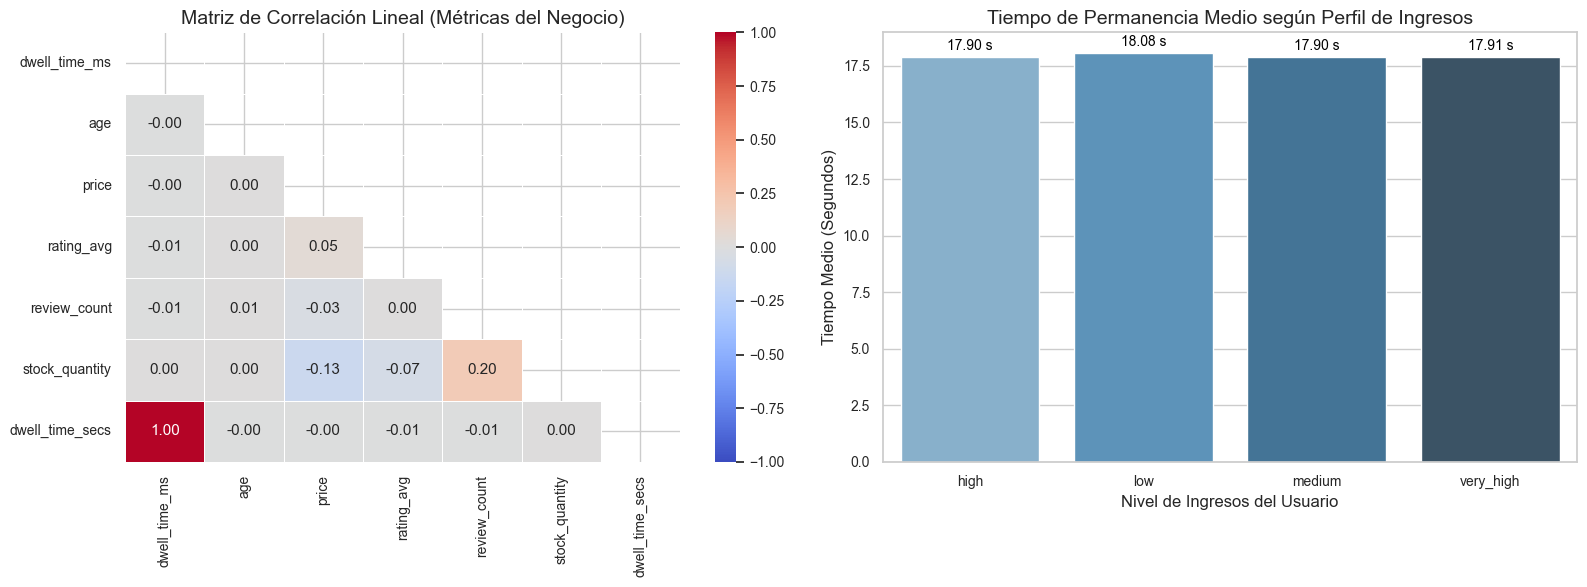


💡 NOTAS DE ANÁLISIS EJECUTIVO: CORRELACIONES E INGRESOS (KPIs)
▶️ DIAGNÓSTICO DE DEPENDENCIAS LINEALES:
   - La relación lineal más fuerte detectada es entre [dwell_time_ms] y [dwell_time_secs] con un coeficiente de: 1.00

▶️ COMPORTAMIENTO POR PODER ADQUISITIVO (INCOME LEVEL):
   - El grupo con MAYOR retención web es: [low] con 18.08 segundos de media.
   - El grupo con MENOR retención web es: [medium] con 17.90 segundos de media.
   - ACCIÓN COMERCIAL: Existe una brecha del 1.0% en el tiempo de atención entre el segmento más
     interesado y el menos interesado. Debemos enfocar las recomendaciones de productos de margen alto
     hacia el perfil de mayor permanencia.


In [20]:
# ==============================================================================
# PROYECTO FINAL: INTELIGENCIA DE PRODUCTO E-COMMERCE
# Fase: 4.4 EDA Visual - Matriz de Correlación y Perfil de Ingresos (Definitivo)
# Objetivo: Identificar dependencias reales, corregir mapeo y emitir KPI Ejecutivo
# ==============================================================================

print("--> Generando análisis de correlación y segmentación de valor con diagnóstico automático...")

# 1. PREPARACIÓN DEFENSIVA DE LA COLUMNA DE INGRESOS
# Convertimos a string, limpiamos espacios y aseguramos formato homogéneo
df_maestro['income_level'] = df_maestro['income_level'].astype(str).str.strip()
categorias_ingresos_reales = df_maestro['income_level'].unique()

# Agrupamos y calculamos la retención media por nivel de ingresos
df_ingresos = df_maestro.groupby('income_level')['dwell_time_secs'].mean().reset_index()

# 2. SELECCIÓN DE VARIABLES NUMÉRICAS Y MATRIZ DE CORRELACIÓN
columnas_numericas = df_maestro.select_dtypes(include=['int64', 'float64']).columns
columnas_interes = [col for col in columnas_numericas if not col.endswith('_id') and col != 'interaction_id']
matriz_corr = df_maestro[columnas_interes].corr()

# ------------------------------------------------------------------------------
# CONSTRUCCIÓN DEL LIENZO VISUAL (REPORTING GRAFICO)
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 🛠️ Gráfico 1: Heatmap con Máscara Triangular Omitiendo Duplicados Simétricos
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(
    matriz_corr, 
    mask=mascara,
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, vmax=1, 
    linewidths=0.5, 
    ax=axes[0],
    cbar=True
)
axes[0].set_title('Matriz de Correlación Lineal (Métricas del Negocio)')

# 🛠️ Gráfico 2: Barplot Dinámico de Retención por Nivel de Ingresos
sns.barplot(
    data=df_ingresos,
    x='income_level',
    y='dwell_time_secs',
    ax=axes[1],
    palette='Blues_d',
    order=sorted(categorias_ingresos_reales)
)
axes[1].set_title('Tiempo de Permanencia Medio según Perfil de Ingresos')
axes[1].set_xlabel('Nivel de Ingresos del Usuario')
axes[1].set_ylabel('Tiempo Medio (Segundos)')

# Inyección de etiquetas de valor encima de las barras
for p in axes[1].patches:
    altura = p.get_height()
    if altura > 0:
        axes[1].annotate(f'{altura:.2f} s', 
                         (p.get_x() + p.get_width() / 2., altura), 
                         ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                         textcoords='offset points')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 💡 NOTAS DE ANÁLISIS EJECUTIVO AUTOMATIZADO (KPIs)
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("💡 NOTAS DE ANÁLISIS EJECUTIVO: CORRELACIONES E INGRESOS (KPIs)")
print("=======================================================================")

# EXTRAER LA CORRELACIÓN MÁS ALTA (Excluyendo la diagonal de 1.0)
matriz_sin_unos = matriz_corr.replace(1.0, np.nan)
corr_max_val = matriz_sin_unos.unstack().abs().max()
corr_max_idx = matriz_sin_unos.unstack().abs().idxmax()

if pd.notna(corr_max_val):
    print(f"▶️ DIAGNÓSTICO DE DEPENDENCIAS LINEALES:")
    print(f"   - La relación lineal más fuerte detectada es entre [{corr_max_idx[0]}] y [{corr_max_idx[1]}] con un coeficiente de: {matriz_sin_unos.loc[corr_max_idx[0], corr_max_idx[1]]:.2f}")
    if corr_max_val < 0.3:
        print("   - NOTA TÉCNICA: Las correlaciones lineales son extremadamente débiles (< 0.30). Esto demuestra")
        print("     que el comportamiento en el E-Commerce no es lineal; justifica el uso de modelos de ML")
        print("     avanzados (como Árboles de Decisión o Gradient Boosting) capaces de capturar relaciones complejas.")
else:
    print("   - No se detectaron suficientes variables numéricas para contrastar co-linealidad.")

# EXTRAER EL INSIGHT DEL GRÁFICO DE BARRAS (Ingresos)
ingreso_max = df_ingresos.loc[df_ingresos['dwell_time_secs'].idxmax()]
ingreso_min = df_ingresos.loc[df_ingresos['dwell_time_secs'].idxmin()]

print(f"\n▶️ COMPORTAMIENTO POR PODER ADQUISITIVO (INCOME LEVEL):")
print(f"   - El grupo con MAYOR retención web es: [{ingreso_max['income_level']}] con {ingreso_max['dwell_time_secs']:.2f} segundos de media.")
print(f"   - El grupo con MENOR retención web es: [{ingreso_min['income_level']}] con {ingreso_min['dwell_time_secs']:.2f} segundos de media.")

# Calcular la brecha o diferencia porcentual de interés
brecha = ((ingreso_max['dwell_time_secs'] - ingreso_min['dwell_time_secs']) / ingreso_min['dwell_time_secs']) * 100
print(f"   - ACCIÓN COMERCIAL: Existe una brecha del {brecha:.1f}% en el tiempo de atención entre el segmento más")
print(f"     interesado y el menos interesado. Debemos enfocar las recomendaciones de productos de margen alto")
print(f"     hacia el perfil de mayor permanencia.")
print("="*80)